# Predicting Airbnb Listing Prices in Melbourne, Australia

---

## 1. Problem Description and Exploratory Data Analysis


### 1.1 Forecasting Problem

**Objective:**

Develop a reliable model for predicting the optimal pricing of Airbnb listings in Melbourne, Australia. The goal is to enhance the efficiency and transparency of the Melbourne Airbnb marketplace by providing data-driven price insights to both supply and demand sides.

**Stakeholders and Benefits:**

- *Hosts*: Accurate price predictions help set competitive yet profitable rates, avoiding Airbnb’s often low suggested pricing.
- *Airbnb Guests*: Insights allow guests to assess if a listing is fairly priced based on its features and market trends.
- *Property Investors*: Supports location selection, property attributes, and investment assessment.
- *Financial Institutions*: Banks and insurers can use these price predictions when assessing loan applications or determining risk factors.
  


### 1.2 Evaluation Criteria

The evaluation metric used is Mean Absolute Error (MAE). MAE measures the average magnitude of the errors between the predicted values and the actual values. Below are the pros and cons in using this metric.


**Pros of MAE:**

- *Simplicity*: Straightforward calculation and easy implementation.

- *Interpretability*: MAE represents the average absolute difference between predicted and actual prices, making it easy to understand.

- *Robustness to Outliers*:  Since MAE does not square errors, extreme values do not disproportionately affect the metric.


**Cons of MAE:**

- *Non-Differentiability at Zero*: The absolute value function lacks smooth differentiation at zero, which can challenge optimization algorithms.
  
- *Equal Weighting of Errors*: Large errors can be more costly in real-world scenarios, but MAE treats all errors equally.




In [2]:
# Import libraries
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science
import numpy as np
import pandas as pd
import shap

# Geospatial data analysis
import geopandas as gpd

# Interactive maps
import folium
from folium.plugins import FastMarkerCluster
from branca.colormap import LinearColormap

# Feature Engineering
from datetime import datetime
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge, ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.model_selection import learning_curve
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.base import clone

# Others
import os
from tqdm import tqdm
import contextily as ctx
import re
import ast
from textblob import TextBlob

In [3]:
# Read dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Set theme and palette color for visualzation
sns.set_theme(style="white")
sns.set_palette("Set2")

In [4]:
# Combine training and test dataset to allow consistent transformations for both sets before training model
#Step 1: Add a marker column to distinguish train vs test
train['is_train'] = 1
test['is_train'] = 0

# Step 2: Add placeholder for 'price' in test to allow column matching
test['price'] = np.nan  # Don't fill with mean/median — just placeholder

# Step 3: Combine
df = pd.concat([train, test], axis=0, ignore_index=True)

### 1.3 Exploring the dataset

In [5]:
# Check all features in both datasets
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 62 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   ID                                            7000 non-null   int64  
 1   source                                        7000 non-null   object 
 2   name                                          6999 non-null   object 
 3   description                                   6943 non-null   object 
 4   neighborhood_overview                         5177 non-null   object 
 5   host_name                                     7000 non-null   object 
 6   host_since                                    7000 non-null   object 
 7   host_location                                 5720 non-null   object 
 8   host_about                                    4730 non-null   object 
 9   host_response_time                            7000 non-null   o

In [6]:
df.head(5)

,ID,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price,is_train
0,0,city scrape,"The Stables, Richmond",Superbly located hotel style accommodation in ...,Richmond is a great neighbourhood. A beautifu...,Ione,16-03-13,"Melbourne, Australia",I'm a working mum who loves being able to shar...,within an hour,...,4.93,4.82,f,2,2,0,0,6.11,$132.00,1
1,1,city scrape,Room in Cool Deco Apartment in Brunswick East,A large air conditioned room with firm queen s...,This hip area is a crossroads between two grea...,Lindsay,16-09-09,"Melbourne, Australia",As an artist working in animation and video I ...,within a few hours,...,4.65,4.60,f,1,0,1,0,1.37,$39.00,1
2,2,city scrape,The Suite @ Angelus Retreat,<b>The space</b><br />Welcome to ANGELUS Retre...,NaN,Margaret Jiin,28-11-11,"Melbourne, Australia",I have very special interests in Life and Life...,within a few hours,...,5.00,4.75,f,2,2,0,0,0.09,$270.00,1
3,3,city scrape,Million Dollar Views Over Melbourne,<b>The space</b><br /><b>Enjoy Million Dollar ...,NaN,Paul,13-06-10,"Melbourne, Australia",Professional couple who enjoy entertaining in ...,within a day,...,5.00,4.00,f,1,0,1,0,0.01,"$1,000.00",1
4,4,city scrape,Melbourne - Old Trafford Apartment,After hosting many guests from all over the wo...,Our street is quiet & secluded but within walk...,Daryl & Dee,12-07-10,"Berwick, Australia",We are an active couple who work from home and...,within a few hours,...,4.90,4.87,f,1,1,0,0,1.43,$116.00,1


*Using `info` and `head` to examine each data type and determine whether it aligns with the nature of the corresponding variables. Below is a categorized list of features by type*


|Variable Type|Number of Features|Feature Names
| --- | --- | --- |
| Numeric | 35| ID, accommodates, availability_30, availability_365, availability_60, availability_90, bathrooms, bedrooms, beds, calculated_host_listings_count, calculated_host_listings_count_entire_homes, calculated_host_listings_count_private_rooms, calculated_host_listings_count_shared_rooms, host_acceptance_rate, host_listings_count, host_response_rate, maximum_maximum_nights, maximum_minimum_nights, maximum_nights, maximum_nights_avg_ntm, minimum_maximum_nights, minimum_minimum_nights, minimum_nights, minimum_nights_avg_ntm, number_of_reviews, number_of_reviews_l30d, number_of_reviews_ltm, review_scores_accuracy, review_scores_checkin, review_scores_cleanliness, review_scores_communication, review_scores_location, review_scores_rating, review_scores_value, reviews_per_month
|
| Ordinal  | 1| host_response_time   |
| Nominal  | 16 | amenities, has_availability, host_has_profile_pic, host_identity_verified, host_is_superhost, host_location, host_name, host_neighbourhood, host_verifications, instant_bookable, name , neighbourhood, neighbourhood_cleansed, source, property_type, room_type
|
|Date | 3| first_review, host_since, last_review|
|Geo coordinates | 2| latitude, longitude|
|Text | 3| description, host_about, neighborhood_overview
|

***To ensure all the features ready to use for modeling, key transformations include:***
- Numeric: price, host_response_rate, and host_acceptance_rate has incorrect data type due to presence of $ , and %. Convertion from string to numbers is needed.
- Ordinal: Assigning numerical values to host response time based on the perceived order of categories.
- Nominal: Use get dummies for nominal variables however consider grouping features with high cardinalities 
- Date: Can be transformed into numerical time-based features, like the difference from the current date or frequency-based analysis
- Geographical coordinates: Latitude & longitude can be used for distance calculations or clustering spatially to uncover locality-based trends.
- Text: Description, host_about, neighborhood_overview could benefit from  sentiment analysis or keyword extraction to determine their impact on listings.



In [7]:
# Correct dtype of price by removing $ and converting to float
df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)

### 1.4 Identify missing Values

<Figure size 1000x1200 with 0 Axes>

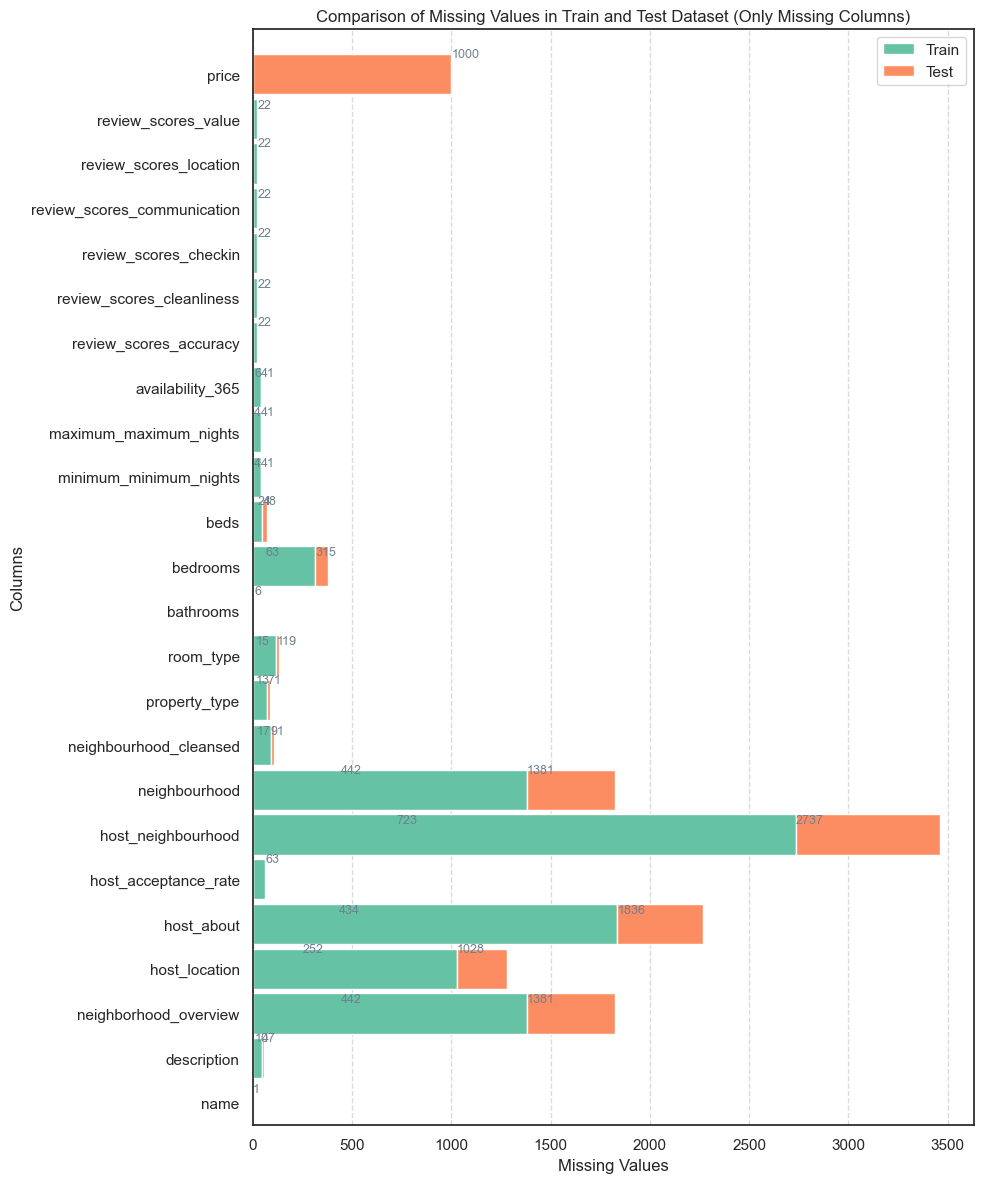

In [8]:
# Horizontal Stacked Bar Chart for both test and training data
# Calculate missing values separately for train and test using 'is_train' flag
train_missing = df[df['is_train'] == 1].isnull().sum()
test_missing = df[df['is_train'] == 0].isnull().sum()

# Create a DataFrame for plotting
missing_df = pd.DataFrame({'Train': train_missing, 'Test': test_missing})

# Keep only columns with missing values
missing_df = missing_df[missing_df.sum(axis=1) > 0]

# Plot missing values as a horizontal bar chart (Stacked)
plt.figure(figsize=(10, 12))
ax = missing_df.plot(kind='barh', stacked=True, figsize=(10,12), width=.9)

# Add labels
for i, p in enumerate(ax.patches):
    if p.get_width() > 0:  
        column_index = i % 2  
        vertical_align = "center" if column_index == 1 else "top"  # Adjust placement

        ax.annotate(f"{int(p.get_width())}", 
                    (p.get_width(), p.get_y() + p.get_height()),  # Place above
                    ha='left', va=vertical_align, fontsize=9, color="slategray")

# Formatting the plot
plt.title("Comparison of Missing Values in Train and Test Dataset (Only Missing Columns)")
plt.ylabel("Columns")
plt.xlabel("Missing Values")
plt.legend(["Train", "Test"])
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.ylim(-0.5, len(missing_df))
plt.tight_layout()
plt.show()

In [9]:
datasets = {'Train': train, 'Test': test, 'Combine': df}

# Create a DataFrame showing missing values for each dataset
missing_summary = pd.DataFrame({
    name: df.isnull().sum()
    for name, df in datasets.items()
})
# Show all features
missing_summary = missing_summary.fillna(0).astype(int)

# Display
pd.set_option('display.max_rows', None)
missing_summary

,Train,Test,Combine
ID,0,0,0
accommodates,0,0,0
amenities,0,0,0
availability_30,0,0,0
availability_365,41,6,47
availability_60,0,0,0
availability_90,0,0,0
bathrooms,6,0,6
bedrooms,315,63,378
beds,48,24,72



***Missing Data Challenges & Implications***

Significant missing values were observed in host-related features (e.g., host_about, host_neighbourhood), impacting contextual understanding. Additionally, review-related columns consistently lacked data across all listings that had yet to receive any reviews. Missing data poses challenges:

- Model Training Issues: Imputation strategies or feature removal must be carefully considered.

- Potential Bias: If data is missing systematically, imputation or deletion could distort predictions.

- Loss of Information: Valuable insights might be compromised due to gaps in data. A consistent approach must be applied across both training and test datasets to maintain model integrity.



### 1.5 Univariate Analysis

Uivariate analysis allows us to detect patterns, identify outliers and prepare data for further analysis.


In [10]:
#Convert to thousands for better readability
def format_thousands(value):
    if abs(value) >= 1000:
        return f'{value / 1000:.1f}K'
    return f'{value:.1f}'

description = df.describe().T
# Apply the formatting to all numeric columns in the description
formatted_description = description.applymap(lambda x: format_thousands(x) if pd.api.types.is_numeric_dtype(type(x)) else x)
formatted_description

,count,mean,std,min,25%,50%,75%,max
ID,7.0K,3.5K,2.0K,0.0,1.7K,3.5K,5.2K,7.0K
host_listings_count,7.0K,15.6,41.6,1.0,1.0,3.0,9.0,292.0
latitude,7.0K,-37.8,0.1,-38.2,-37.9,-37.8,-37.8,-37.5
longitude,7.0K,145.0,0.2,144.5,145.0,145.0,145.1,145.8
accommodates,7.0K,3.8,2.5,1.0,2.0,4.0,5.0,16.0
bedrooms,6.6K,1.8,1.1,1.0,1.0,1.0,2.0,14.0
beds,6.9K,2.3,1.8,1.0,1.0,2.0,3.0,22.0
minimum_nights,7.0K,4.3,17.9,1.0,1.0,2.0,3.0,1.1K
maximum_nights,7.0K,712.2,503.7,1.0,90.0,1.1K,1.1K,10.0K
minimum_minimum_nights,7.0K,3.8,11.1,1.0,1.0,2.0,3.0,360.0


**Key insights:**

-  `host_listings_count` => max of 292 suggest presence of professional hosts

-  `minimum_maximum_nights`, `maximum_maximum_nights`, `maximum_nights_avg_ntm` => values exceed 2 million which is unusual

-  *Review Scores & Guest Satisfaction columns* - Most review related metrics have high mean values of about 4.7 to 4.8 suggesting strong guest satisfaction

**Key Insights on Price Distribution**

- Right-skewed distribution: Most listings cluster at lower prices, while a few outliers exceed $100K.

- Average price: 285.1, but a high standard deviation of 2.5K suggests price variability.

- Median price: 170, indicating most listings fall on the lower end. MAE remains the best metric, as it minimizes outlier sensitivity

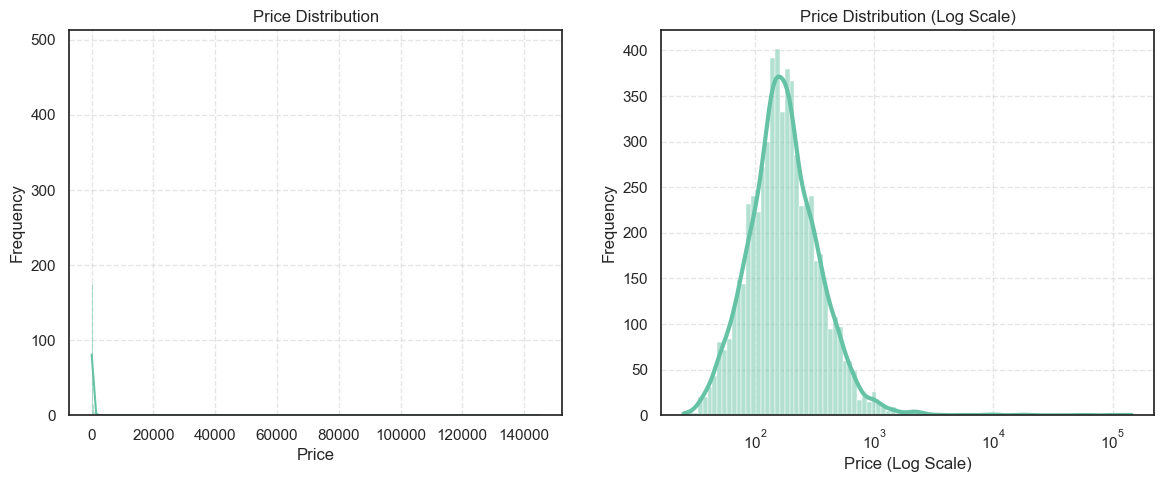

In [75]:
plt.figure(figsize=(14, 5))

# Histogram of original price distribution
plt.subplot(1, 2, 1)
sns.histplot(train["price"], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)

# Histogram of price distribution using logarithmic scale
plt.subplot(1, 2, 2)
sns.histplot(train["price"], kde=True, log_scale=True, line_kws={'linewidth': 3})
plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (Log Scale)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Price Distribution**
- Raw `price` distribution is extremely right skewed with nearly all 6,000 observations compressed into the left bar and making the rest of the distribution disappeared. This means trainning any model directly on raw `price` means the loss function will be dominated by a tiny number of extreme listings.

- There are 5 extreme outliers in this dataset outside 99.99 percentiles, which can affect the prediction

**Log Price Distribution**
- The chart is close to normal distribution with a slightly right-skewed, making it a more suitable target for regression models than `price`. It has a clear peak around $100-$300 (the $10²–$10²·⁵ range) and a right tail extends to $10⁵ showing a handful of luxury listings remain influential even after log transformation.

In [78]:
# Calculate the 5th and 99.99th percentiles of the price column
q_low = df["price"].quantile(0.05)
q_high = df["price"].quantile(0.999)

# Count how many observations have price higher than q_high
num_above_q_high = (df["price"] > q_high).sum()
num_below_q_low = (df["price"] < q_low).sum()

print('q_low:', q_low)
print('q_high:', q_high)
print('Number of observations with price < q_low:', num_below_q_low)
print('Number of observations with price > q_high:', num_above_q_high)

q_low: 59.0
q_high: 9999.0
Number of observations with price < q_low: 287
Number of observations with price > q_high: 5


**Key Insights and Relationships between key features to Price:**

The distribution is right-skewed, as most listings have fewer amenities. However, the tail suggests that a smaller segment offers significantly more space and capacity. This indicates a positive relationship between these features and price-lower-count listings tend to be mid-range, while high-count listings are likely more expensive, contributing to the overall right skew in price distribution.

In [12]:
# Filter selected columns
# Select columns
selected_columns = ['price','accommodates', 'beds',  'bedrooms']
filtered_description = description.loc[selected_columns]

# Apply the formatting function to numeric values
formatted_description = filtered_description.applymap(lambda x: format_thousands(x) if pd.api.types.is_numeric_dtype(type(x)) else x)
formatted_description

,count,mean,std,min,25%,50%,75%,max
price,6.0K,285.1,2.5K,25.0,113.0,170.0,264.0,145.2K
accommodates,7.0K,3.8,2.5,1.0,2.0,4.0,5.0,16.0
beds,6.9K,2.3,1.8,1.0,1.0,2.0,3.0,22.0
bedrooms,6.6K,1.8,1.1,1.0,1.0,1.0,2.0,14.0


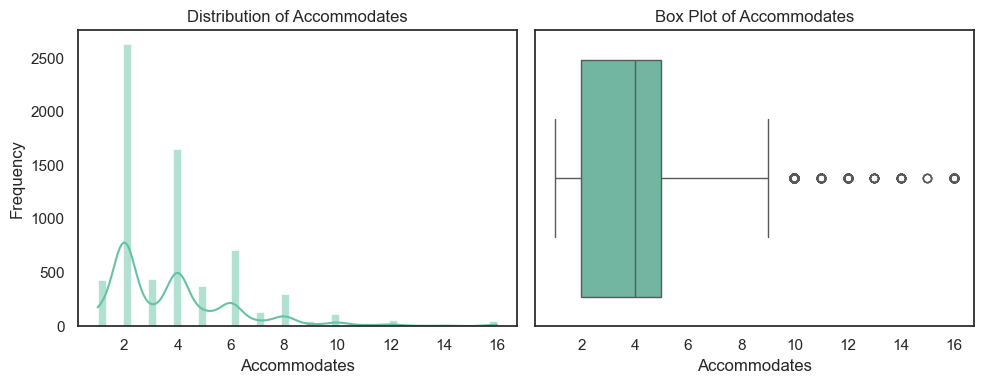

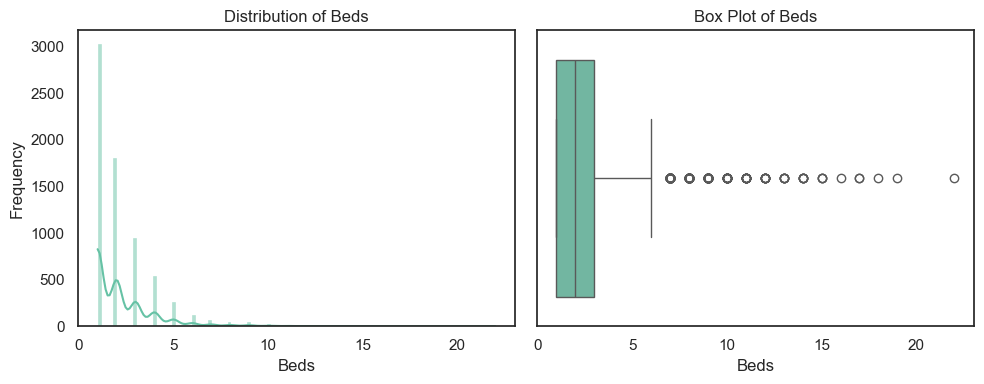

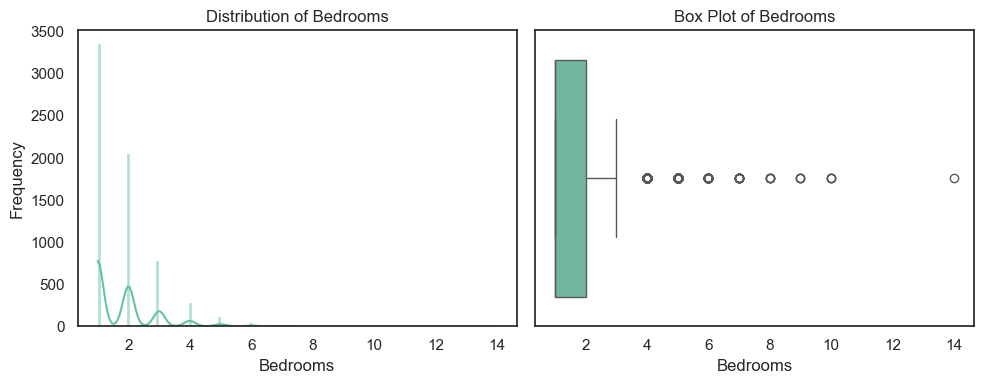

In [13]:
# Other univariate features
features_to_plot = ['accommodates', 'beds',  'bedrooms' ]

for feature in features_to_plot:
    plt.figure(figsize=(10, 4)) 

    # Histogram subplot
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Frequency')

    # Box plot subplot    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[feature].dropna())
    plt.title(f'Box Plot of {feature.capitalize()}')
    plt.xlabel(feature.capitalize())

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

---

## 2. Data Cleaning, Tranformation and Feature Engineering

### 2.1 Data Cleaning

To prepare the dataset for modeling, it is essential to clean all the numerical features. Steps to clean all the numerical features:
1. **Identify numerical features** that are stored as object types
   - Some features are currently stored  as object (strings) due to the presence of non-numeric characters (symbols or text)
     
2. **Remove the symbols**

   - `$` in `price`  (already performed in Task 1)
   - `%` in `host_response_rate`, `host_acceptance_rate` 
3. **Convert the cleansed string to float or integer** using `astype(float)` and `pd.to_numeric()`
4. **Convert  textual format** for `bathrooms` to numeric by defining and applying a function to handle it


In [14]:
# Remove the symbol % in host_response_rate, host_acceptance_rate
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
            df[col] = train[col].astype(str).str.replace(r'[%,]', '', regex=True)
            df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
# Define a function to convert column bathrooms
def convert_bathrooms_column(df, column='bathrooms'):
    """
    Converts a textual 'bathrooms' column into numeric values.
    Handles phrases like '1 bath', '1.5 baths', 'shared bath', 'half bath', etc.

    Parameters:
        df (pd.DataFrame): Input DataFrame containing a 'bathrooms' column.
        column (str): Column name to convert. Default is 'bathrooms'.

    Returns:
        pd.DataFrame: DataFrame with the specified column converted to numeric.
    """
    num_baths = []

    for item in df[column]:
        if isinstance(item, str): # Check if the value is a string
            item_lower = item.lower()
            if 'bath' in item_lower:
                value_str = item_lower.replace(' baths', '').replace(' bath', '').replace(' shared', '').replace(' private', '')
                if 'half' in value_str:
                    value = 0.5
                else:
                    try:
                        value = float(value_str)
                    except ValueError:
                        value = np.nan
                num_baths.append(value)
            else:
                num_baths.append(np.nan)
        else:
            num_baths.append(np.nan)

    df = df.copy()
    df[column] = num_baths
    return df

# Convert number of bathrooms
df = convert_bathrooms_column(df)

### 2.2 Data Transformation

We identify and transform columns with multiple pieces of information into meaningful new features:
1. `host_verification`
- **Description**: a list containing verification methods such as email and phone
- **New feature**: `num_verifications` - count the number of verification methods per host

2. `host_since` 
- **Description**: the date the host started listing on Airbnb
- **New feature**: `days_hosting` - calculate the number of days between the `host_since` date and today
  
3. `amenities_list` 
- **Description**: a comma-separated list of all the amenities available for each property
- **New feature**: `num_amenities` - count the number of amenities listed for the property
  
4. `neighborhood_cleansed` 
- **Description**: the suburb or neighborhood of the property
- **New feature**: `region` - map each neighborhood to a broader region in Melbourne


In [16]:
# Convert host_verifications to number of verification methods
df['host_verifications'] = df['host_verifications'].apply(lambda x: ast.literal_eval(x))
df['num_verifications'] = df['host_verifications'].apply(len)

# Drop the original column
df = df.drop(columns = 'host_verifications')

In [17]:
# Convert date variables to correct format and calculate `day_hosting`

# Convert host_since to datetime
df['host_since'] = pd.to_datetime(df['host_since'], format='mixed')

# Calculate days_hosting
df['days_hosting'] = (pd.to_datetime(datetime.now().date()) - df['host_since']).dt.days

# Drop the original column
df = df.drop(columns='host_since')

In [18]:
# Parse amenities column and convert them into lists
df['amenities_list'] = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Calculate the number of amenities per row
df['num_amenities'] = df['amenities_list'].apply(len)

In [19]:
# Create Reggion mapping for neighbourhood) and drop neighborhood cleansed column 
region_mapping = {
    'North': ['Moreland', 'Darebin', 'Banyule', 'Hume', 'Whittlesea'],
    'South': ['Bayside', 'Kingston', 'Frankston', 'Glen Eira', 'Port Phillip', 'Stonnington'],
    'East': ['Whitehorse', 'Manningham', 'Monash', 'Knox', 'Maroondah', 'Yarra Ranges'],
    'West': ['Hobsons Bay', 'Maribyrnong', 'Wyndham', 'Brimbank', 'Melton', 'Moonee Valley'],
    'Central': ['Melbourne', 'Yarra', 'Boroondara']
}

# Function to assign region based on mapping
def assign_region(neighbourhood):
    for region, areas in region_mapping.items():
        if neighbourhood in areas:
            return region
    return 'Other'  # Default for unclassified areas

# Apply function to create a new 'Region' column
df['region'] = df['neighbourhood_cleansed'].apply(assign_region)
df['region'].unique()

array(['Central', 'North', 'East', 'Other', 'South', 'West'], dtype=object)

### 2.3 Data Imputation

To ensure the dataset is ready for modeling, we impute missing values by the mean, mode and median of the variables based on their type of data and distribution:
1. **Define functions to fill missing values**:
   - `fill_numerical_with_mean()`
   - `fill_categorical_with_mode()`
   - `fill_numerical_with_median()`

2. **Imputation Strategy**:
   - Use **mean** for normally distributed numerical variables.
   - Use **mode** for categorical variables.
   - Use **median** for numerical variables with skewed distributions or outliers.

3. **Visualize variable distributions**  
   Visualized the distribution of each variable to determine the appropriate imputation method.

4. **Apply the functions for imputation**
- Numerical variables filled using **mean** for `host_response_rate`, `host_acceptance_rate`
- Categorical variables filled using **mode** for `host_is_superhost`, `room_type`, `host_response_time`
- Numerical variables filled using **median** for for
  `bathrooms`
  `bedrooms`
  `beds`
  `review_scores_rating`
  `review_scores_accuracy`
  `review_scores_cleanliness`
  `review_scores_checkin`
  `review_scores_communication`
  `review_scores_location`
  `review_scores_value`
  `minimum_minimum_nights`
  `maximum_maximum_nights`
  `reviews_per_month`

5. **Addtional imputation**
   - To impute the missing value in `availability_365`, we assume that the availability of a year (365 days) is 4 times the availability of 90 days

In [20]:
# Filling missing values for numerical variables
def fill_numerical_with_mean(df, columns):
    """
    Fills missing values in specified numerical columns with the mean.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        columns (list): List of numerical column names to fill.

    Returns:
        pd.DataFrame: DataFrame with missing values filled.
    """
    df = df.copy()
    numerical_subset = df[columns]
    mean_values = numerical_subset.mean()
    numerical_subset.fillna(mean_values, inplace=True)
    df[columns] = numerical_subset
    return df

# Filling missing values for categorical variables
def fill_categorical_with_mode(df, columns):
    """
    Fills missing values in specified categorical columns with the mode.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        columns (list): List of categorical column names to fill.

    Returns:
        pd.DataFrame: DataFrame with missing values filled.
    """
    df = df.copy()
    categorical_subset = df[columns]
    mode_values = categorical_subset.mode().iloc[0]
    categorical_subset.fillna(mode_values, inplace=True)
    df[columns] = categorical_subset
    return df

# Filling missing values for numerical variables
def fill_numerical_with_median(df, columns):
    """
    Fills missing values in skewed distribution numerical columns with the median.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        columns (list): List of numerical column names to fill.

    Returns:
        pd.DataFrame: DataFrame with missing values filled.
    """
    df = df.copy()
    numerical_subset = df[columns]
    median_values = numerical_subset.median()
    numerical_subset.fillna(median_values, inplace=True)
    df[columns] = numerical_subset
    return df

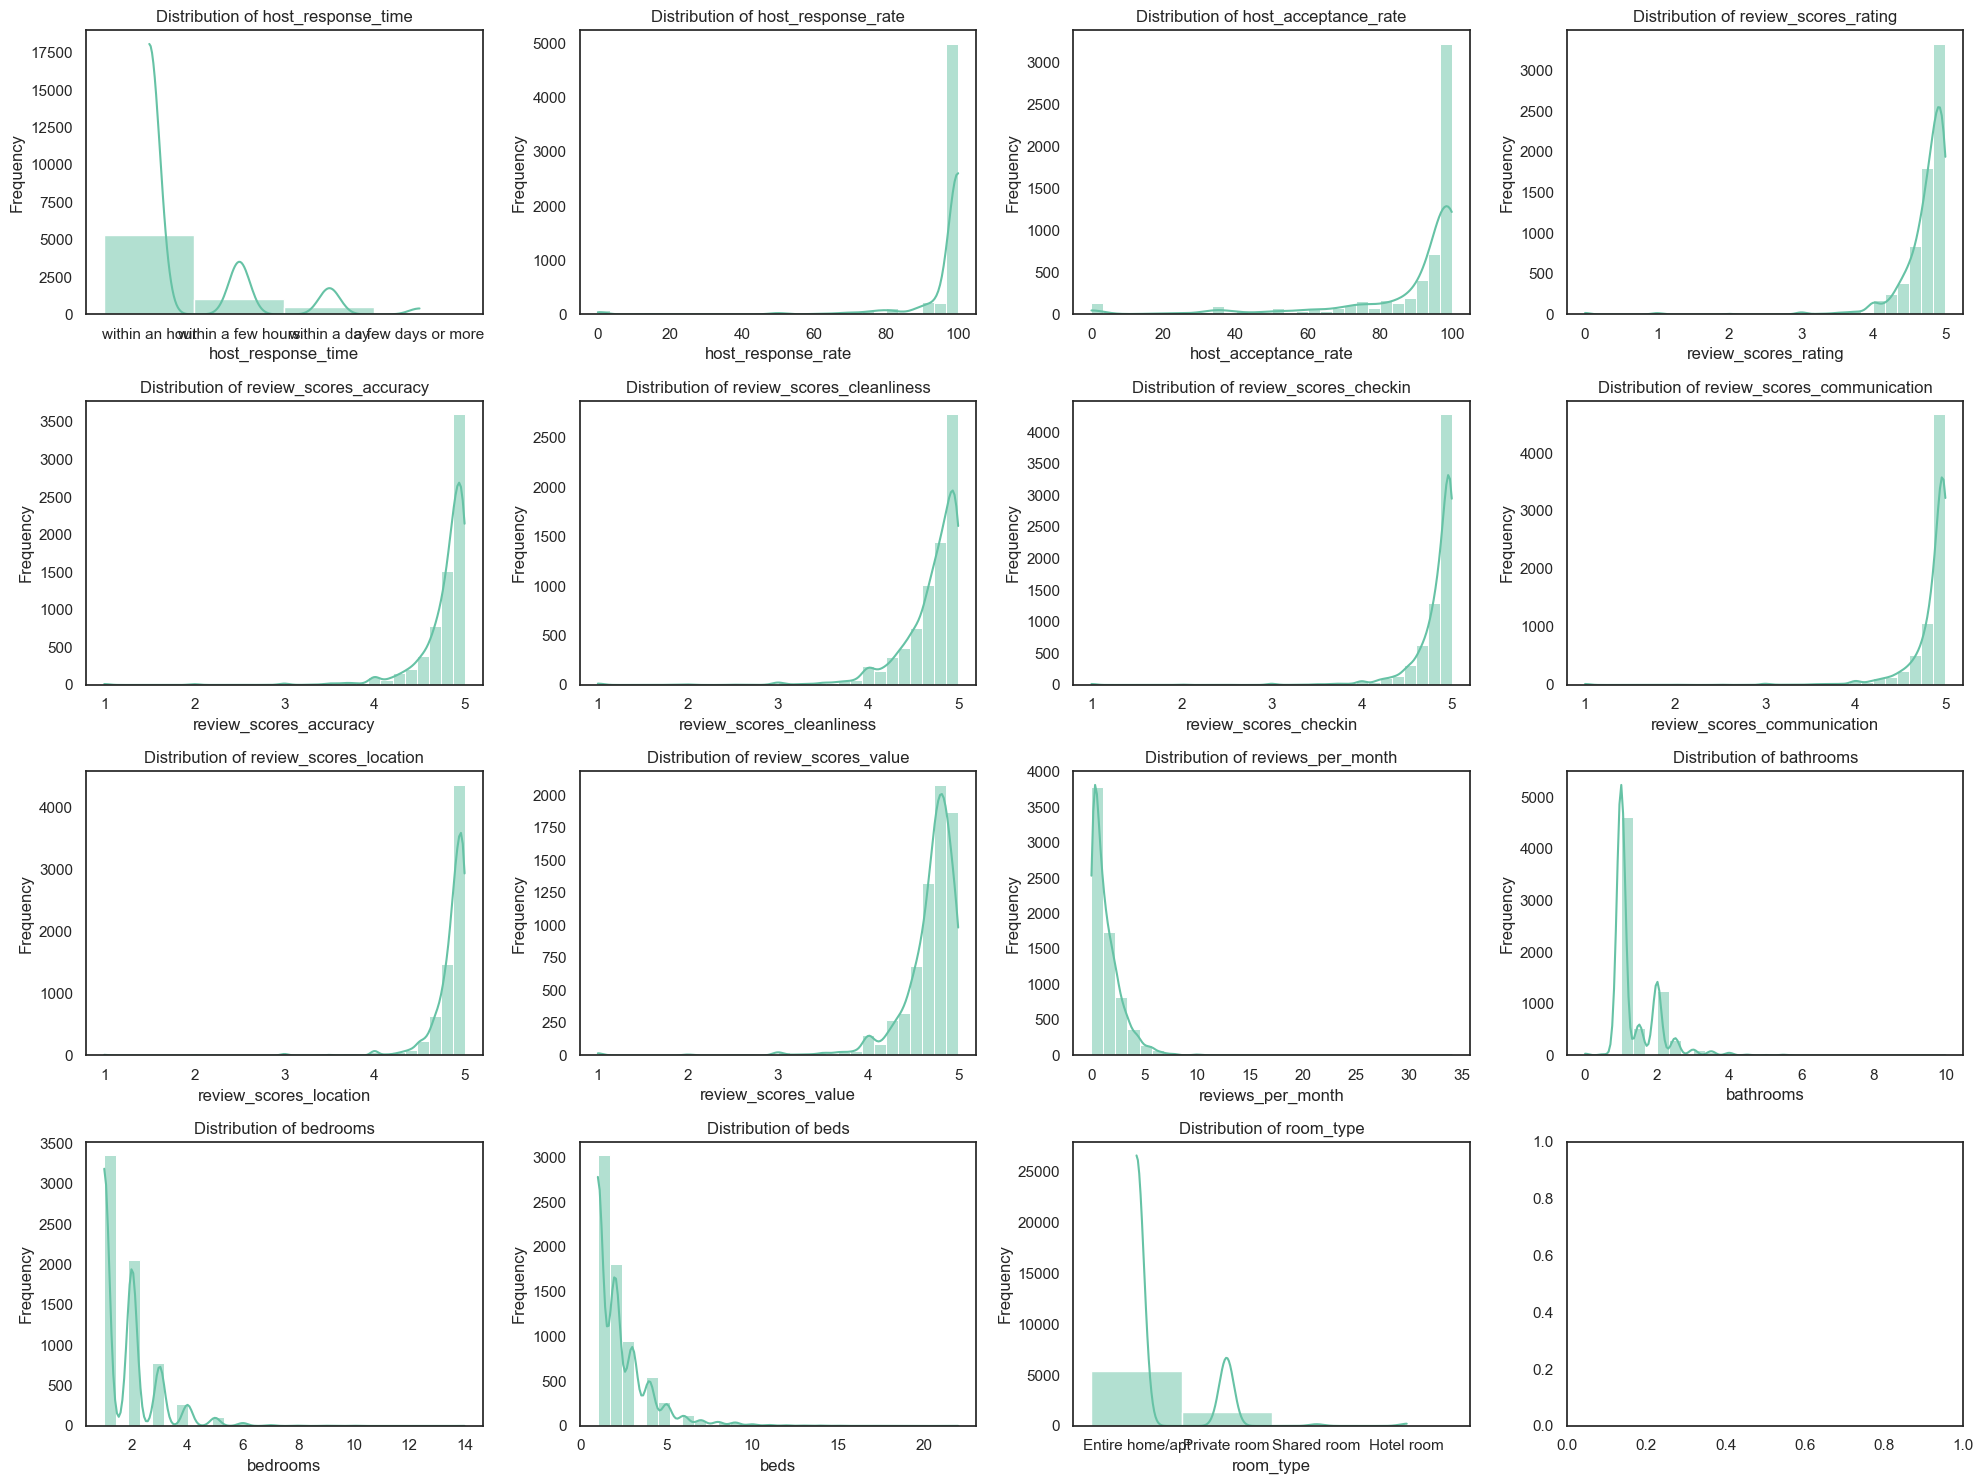

In [21]:
# Create subplots for the histograms
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))
axes = axes.flatten() 

# List of columns to plot
columns_to_plot = [
    'host_response_time',
    'host_response_rate',
    'host_acceptance_rate',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'bathrooms',
    'bedrooms',
    'beds',
    'room_type'
]

# Create histograms for each column
for i, column in enumerate(columns_to_plot):
    sns.histplot(df[column].dropna(), bins=30, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [22]:
# Filling missing values for numerical variables by mean value
df = fill_numerical_with_mean(df, ['host_response_rate','host_acceptance_rate'])

In [23]:
# Filling missing values for categorical variables by mode value
df = fill_categorical_with_mode(df, ['host_is_superhost','room_type', 'host_response_time'])

In [24]:
# Filling missing values for numerical variables with skewed distribution by median value
df = fill_numerical_with_median(df, [
    'bathrooms',
    'bedrooms',
    'beds',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'minimum_minimum_nights', 
    'maximum_maximum_nights',
    'reviews_per_month'
])

In [25]:
# Fill missing values in 'availability_365' using 4x 'availability_90'
df['availability_365'] = df['availability_365'].fillna(df['availability_90'] * 4)

### 2.4 Encoding

To prepare the categorical variables, we check the unique values of categorical variables and apply the encoding process:
1. **Binary variables** (`t`/`f`)

The following features contain only two values: `t` and `f`, which will be mapped to binary `1` and `0` respectively.

- `has_availability`, `host_has_profile_pic`, `instant_bookable`, `host_is_superhost`, `host_identity_verified`

2. **Ordinal variable**

`host_response_time` is the ordinal variable with ordered categories. We will encode with the response increasing integers based on the responsiveness.
  - `'within an hour'` → 0
  - `'within a few hours'` → 1
  - `'within a day'` → 2
  - `'a few days or more'` → 3

3. **High cardinality nominal variable**

To reduce dimensionality, we will group the values in these features into 6 categories before encoding.

- `property_type` has 74 unique values. We group this feature into a new column named `property_type_grouped` into 6 categories:
    - **House/Home**: Includes listings like "Entire home", "Entire cabin", "Entire vacation home", etc.
    - **Apartment/Condo**: Includes units like "Entire rental unit", "Entire condo", "Loft", "Serviced apartment", etc.
    - **Hotel**: Includes rooms in boutique hotels, B&Bs, and hostels.
    - **Private Room**: If `"Private room"` appears in the type.
    - **Shared Room**: If `"Shared room"` appears.
    - **Other**: For all other or missing values

- `neighbourhood_cleansed` has 30 unique values. 
    - We replace missing values with `Other`
    - Identify top 5 most frequent neighborhoods based on value counts
    - All neighborhoods outside top 5 will be grouped in `Other`
      
4. **Encode nominal variables**

We apply `pd.get_dummies()` to these nominal categorical variables: `region`, `room_type`, `property_type_grouped`, `neighbourhood_cleansed`

In [26]:
# Get all columns with object datatype
categorical_columns = df.select_dtypes(include=['object']).columns

# Remove irrelevant features from the list
categorical_columns = categorical_columns.difference(['source', 'host_location', 'host_name','name', 'host_about', 'amenities','amenities_list',
                                                      'description', 'neighbourhood', 'host_neighbourhood', 'neighborhood_overview',
                                                      'host_neighbourhood','first_review', 'last_review'])

# Loop through each categorical column and check the number of unique values
for col in categorical_columns:
  unique_values = df[col].nunique()
  if unique_values > 5:
    print(f"{col}: {unique_values} unique values")
  else:
    print(f"{col}: {df[col].unique()}")

has_availability: ['t']
host_has_profile_pic: ['t' 'f']
host_identity_verified: ['t' 'f']
host_is_superhost: ['f' 't']
host_response_time: ['within an hour' 'within a few hours' 'within a day' 'a few days or more']
instant_bookable: ['f' 't']
neighbourhood_cleansed: 30 unique values
property_type: 65 unique values
region: 6 unique values
room_type: ['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']


In [27]:
# Convert 't'/'f' to binary values '1'/'0'
for col in ['has_availability', 
            'host_has_profile_pic',
            'instant_bookable', 
            'host_is_superhost', 
            'host_identity_verified']:
    df[col] = df[col].astype(str).str.lower().replace({'t': '1', 'f': '0'}).astype(int)

In [28]:
# Ordinal encoding for host_response_time
response_time_order = [
    'within an hour',
    'within a few hours',
    'within a day',
    'a few days or more'
]
df['host_response_time'] = df['host_response_time'].map(
    {val: i for i, val in enumerate(response_time_order)}
)

In [29]:
# Grouping logic for property types
def group_property_type(property_type):
    if pd.isnull(property_type):  # Handle missing values
        return "Other"
    elif property_type in ['Entire home', 'Entire guesthouse', 'Entire bungalow', 'Entire cottage', 'Entire vacation home', 'Entire cabin', 'Earthen home', 'Entire chalet', 'Farm stay']:
        return 'House/Home'
    elif property_type in ['Entire rental unit', 'Entire loft', 'Entire condo', 'Entire serviced apartment', 'Room in serviced apartment', 'Entire Place']:
        return 'Apartment/Condo'
    elif property_type in ['Room in boutique hotel','Room in bed and breakfast','Private room in hostel']:
        return 'Hotel'
    elif 'Private room' in property_type:
        return 'Private Room'
    elif 'Shared room' in property_type:
        return 'Shared Room'
    else:
        return 'Other'

# Create a new column 'property_type_grouped'
df['property_type_grouped'] = df['property_type'].apply(group_property_type)

# Print the unique values of property_type_grouped
df['property_type_grouped'].unique()

# Drop original property column
df = df.drop(columns = 'property_type')

In [30]:
# Fill missing values in neighborhood_cleansed
df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].fillna('Other')

# Get top 5 neighborhoods
top5_neighbourhoods = df['neighbourhood_cleansed'].value_counts().nlargest(5).index

df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].apply(
    lambda x: x if x in top5_neighbourhoods else 'Other'
)


In [31]:
# Encoding for Nominal Features
columns_to_encode = [
    'region',
    'room_type',
    'property_type_grouped', 
    'neighbourhood_cleansed'
]

for col in columns_to_encode:
    dummies = pd.get_dummies(df[col], prefix=col, prefix_sep='__', drop_first=True, dummy_na=True, dtype=int)
    df = pd.concat([df.drop(columns=[col]), dummies], axis=1)

### 2.5 Feature Engineering

Before modeling, we perform some additional data cleaning and feature engineering to enhance data quality, reduce noise and extract meaningfull patterns from the dataset.
1. **Remove irrelevant columns**

- Drop ID and unstructured text columns not useful for modeling
- Drop some original columns after extracting relevant engineered features
- Drop `first_review` and `last_review` due to high amount of missing values in test dataset
- Drop `minimum_maximum_nights`, `maximum_maximum_nights`, `maximum_nights_avg_ntm` due to unsual values

2. **Create new features** by computing the ratios, density and likelihood features:

   - `bed_to_bath_ratio`
   - `guest_comfort_score`
   - `room_density`
   - `review_density`
   - `availability_ratio`
   - `superhost_verified`
   - `high_review_count`
   - `short_stay_friendly`
   - `occupancy_proxy`

3. **Geospatial Feature**: distance to the nearest train station and distance to CBD

   - Identify 15 major train stations and CBD of Melbourne
   - Using the Haversine formula to compute the distance from each property to every station and CBD
   - Keep the minimum distance as the new feature


4. **Text and sentiment-based feature engineering**.


   - Extract polarity (positive/negative) and subjectivity for `host_about` and `description` to capture how enthusiastic and informative of the host and property

In [32]:
# Remove columns not relevant to the analysis and those that are redundant
columns_to_remove = ['ID', 'source', 'name', 'neighborhood_overview', 
                     'host_name', 'host_location', 'host_neighbourhood', 'neighbourhood',
                     'amenities', 'amenities_list']

# Remove the specified columns
df = df.drop(columns=columns_to_remove)

# Remove these columns due to high amount of missing values in test dataset
df = df.drop(columns= ['first_review','last_review', 'minimum_maximum_nights', 'maximum_maximum_nights', 'maximum_nights_avg_ntm'])

In [33]:
# Bed-to-bath ratio
df['bed_to_bath_ratio'] = (df['beds'] / df['bathrooms'].replace(0, np.nan)).fillna(0)

# Guest comfort score
df['guest_comfort_score'] = (df['beds'] + df['bedrooms']) / df['accommodates'].replace(0, np.nan)
df['guest_comfort_score'] = df['guest_comfort_score'].fillna(0)

# Room density
df['room_density'] = df['accommodates'] / (df['bedrooms'] + 1)

# Review density
df['review_density'] = (df['number_of_reviews_ltm'] / df['availability_365'].replace(0, np.nan)).fillna(0)

In [34]:
# Availability Ratio
df['availability_ratio'] = df['availability_365'] / 365

# Superhost & Verified Interaction
df['superhost_verified'] = df['host_is_superhost'] * df['host_identity_verified']

# Booking Likelihood Features
df['reviews_per_month'] = df['number_of_reviews_ltm'] / 12
df['high_review_count'] = (df['number_of_reviews_ltm'] > df['number_of_reviews_ltm'].median()).astype(int)

# Weekend-Friendly Listings
df['short_stay_friendly'] = (df['minimum_nights'] <= 2).astype(int)

# Occupancy Proxy Feature
df['occupancy_proxy'] = df['reviews_per_month'] * df['availability_365']

In [35]:
# Define major Melbourne train stations with lat/lon
melbourne_stations = pd.DataFrame({
    'station': [
        'Flinders Street', 'Southern Cross', 'Melbourne Central', 'Parliament', 'Flagstaff',
        'Richmond', 'South Yarra', 'Jolimont', 'North Melbourne', 'Footscray',
        'Caulfield', 'Glenferrie', 'Camberwell', 'Box Hill', 'Dandenong'
    ],
    'latitude': [
        -37.8180, -37.8183, -37.8102, -37.8116, -37.8105,
        -37.8241, -37.8391, -37.8162, -37.8013, -37.7990,
        -37.8770, -37.8223, -37.8277, -37.8181, -37.9852
    ],
    'longitude': [
        144.9671, 144.9526, 144.9631, 144.9735, 144.9545,
        144.9980, 144.9937, 144.9830, 144.9420, 144.9011,
        145.0434, 145.0350, 145.0613, 145.1193, 145.2155
    ]
})

# Define a function to compute the distance
def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of Earth in km
    return c * r

# For each listing, compute distance to each station, keep the minimum
def min_station_distance(row):
    distances = haversine(row['latitude'], row['longitude'], melbourne_stations['latitude'], melbourne_stations['longitude'])
    return distances.min()

# Apply the function and create a new feature for distance to the nearest station
df['min_station_distance_km'] = df.apply(min_station_distance, axis=1)

In [36]:
# Melbourne CBD coordinates
CBD_LAT = -37.8136
CBD_LON = 144.9631

# Compute distance to CBD for each listing
df['cbd_distance_km'] = df.apply(
    lambda row: haversine(row['latitude'], row['longitude'], CBD_LAT, CBD_LON),
    axis=1
)

In [37]:
# Handle missing values and compute sentiment polarity for host_about column
df['host_about_sentiment'] = df['host_about'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)

# Compute subjectivity score
df['host_about_subjectivity'] = df['host_about'].fillna('').apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Handle missing values and compute sentiment polarity for description column
df['description_sentiment'] = df['description'].fillna('').apply(
    lambda x: TextBlob(x).sentiment.polarity)

# Compute subjectivity score
df['description_subjectivity'] = df['description'].fillna('').apply(
    lambda x: TextBlob(x).sentiment.subjectivity)

In [38]:
# Remove text column before modeling
df = df.drop(columns= ['description','host_about'])

### 2.6 Log Transformation for Target Variable

Log-transform `price` is performed to compress the scale so extreme values are less damaging without discarding them. Train and evaluate on log scale, then exponentiate predictions back.

In [39]:
# Then log transform
df['log_price'] = np.log1p(df['price'])

**After preprocessing, dataset is seperated back to train and test dataset before modeling**

In [40]:
# Separate them again after preprocessing
train = df[df['is_train'] == 1].drop(columns=['is_train'])
test = df[df['is_train'] == 0].drop(columns=['is_train', 'price', 'log_price'])  # drop target from test

--- 
## 3. Exploratory Data Analysis


### 3.1 Visualization of listings

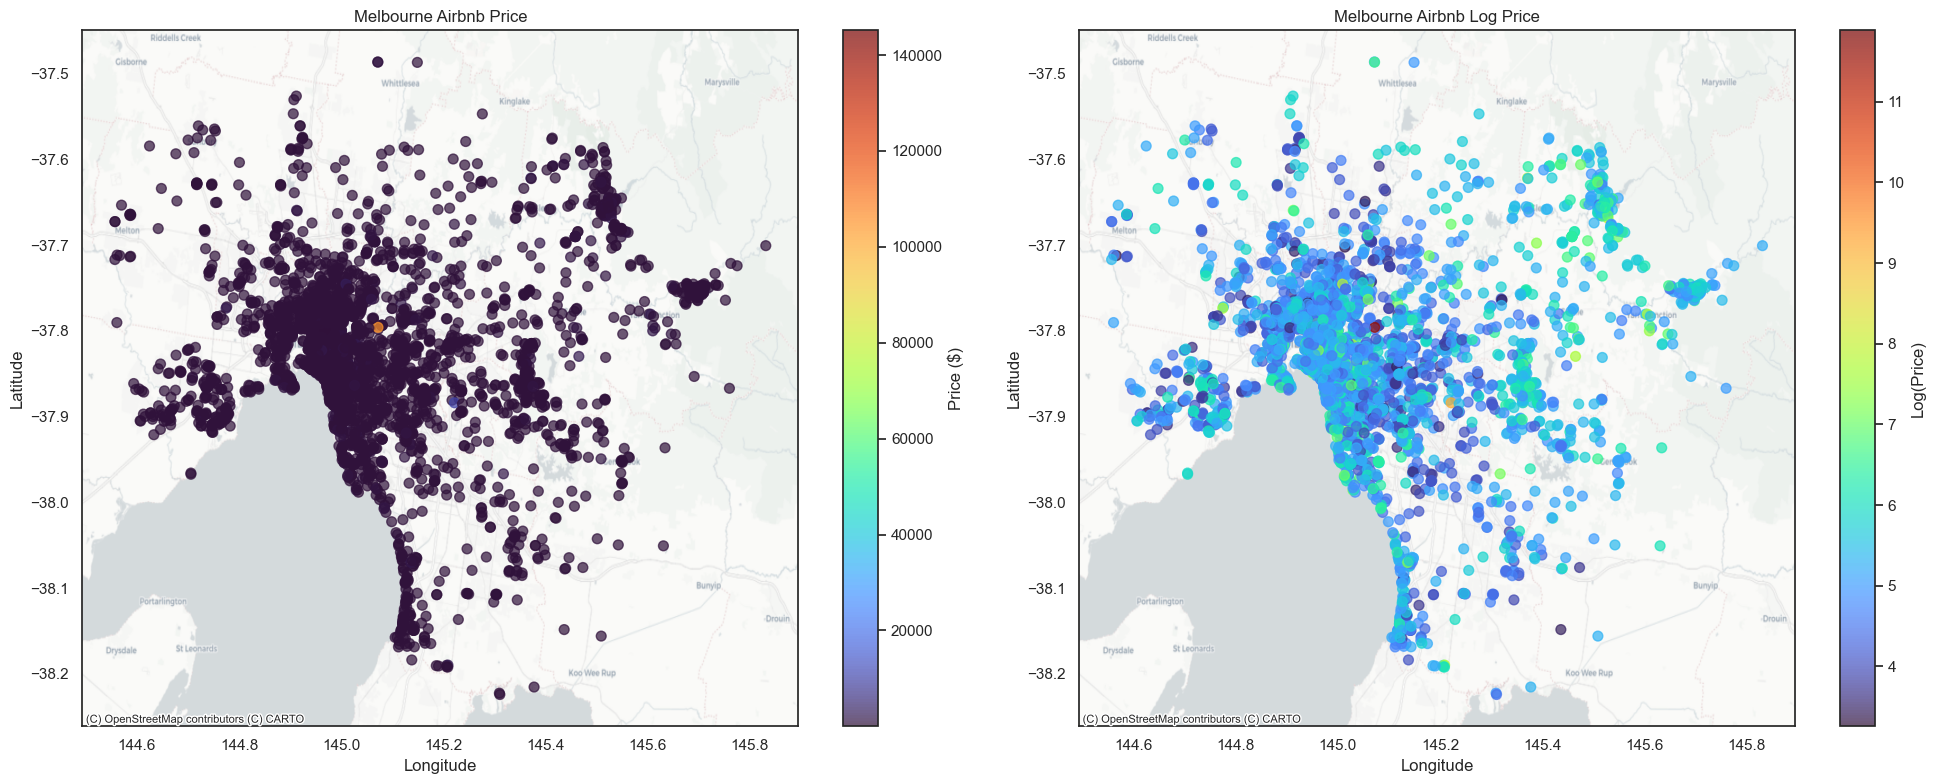

In [41]:
# Create a single figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Standard Price
# Plot directly on the first axis (ax1)
sc1 = ax1.scatter(train['longitude'], train['latitude'], 
                  c=train['price'], cmap='turbo', alpha=0.7, 
                  edgecolors='face', s=50)

# Add the base map specifically to ax1
ctx.add_basemap(ax1, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron)

# Add labels, title, and colorbar using the ax1 object
fig.colorbar(sc1, ax=ax1, orientation="vertical", label="Price ($)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("Melbourne Airbnb Price")

# RIGHT PLOT: Log Price
# Plot directly on the second axis (ax2)
sc2 = ax2.scatter(train['longitude'], train['latitude'], 
                  c=train['log_price'], cmap='turbo', alpha=0.7, 
                  edgecolors='face', s=50)

# Add the base map specifically to ax2
ctx.add_basemap(ax2, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron)

# Add labels, title, and colorbar using the ax2 object
fig.colorbar(sc2, ax=ax2, orientation="vertical", label="Log(Price)")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("Melbourne Airbnb Log Price")

# Adjust layout so labels don't overlap, then show
plt.tight_layout()
plt.show()

The plot of raw `price` clearly shows that there is a few extremely expensive listings (there appears to be at least one listing pushing up towards $140,000+). 

After applying log transformation, we can see the actual trends of the listings. There is a distinct concentration of higher-priced rentals (greens, yellows, and oranges) right around the Melbourne CBD. The cooler shades (blues and purples) are clustered further out in the outer suburbs, which aligns perfectly with real-world real estate trends

### 3.2 Correlation Heatmap

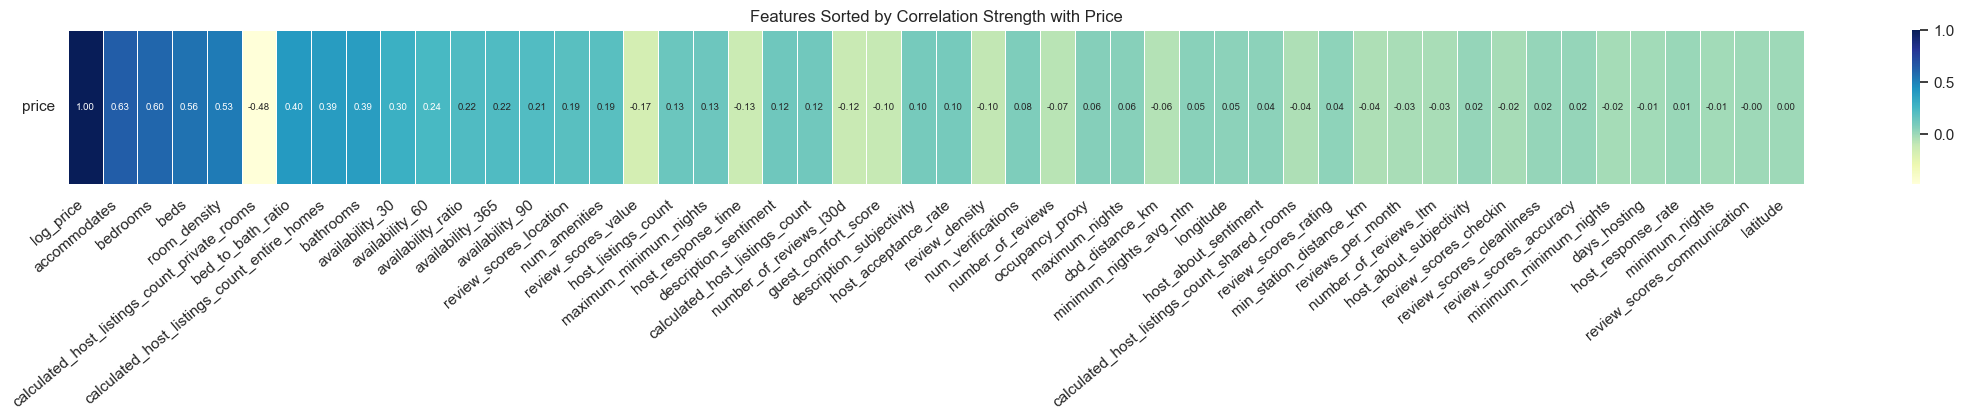

In [42]:
cols = [col for col in train.columns if col != 'price'] + ['price']
train = train[cols]

# Compute correlation
corr = train.select_dtypes(include=['int64','float64']).corr(method='spearman')

price_corr = corr.loc['price'].drop('price')
sorted_corr = price_corr.reindex(price_corr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(28, 2))  
sns.heatmap(
    sorted_corr.to_frame().T,  
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar=True,
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.yticks(rotation=0)
plt.xticks(rotation=40, ha='right')
plt.title("Features Sorted by Correlation Strength with Price", fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 Correlation Insights from Training Data


Based on the Spearman rank correlations between top 16 feature and the target variable (`price`) in the training dataset, we observed the following:

**Structural Scale & Capacity (The Primary Price Drivers)**
- `accommodates` ($r = 0.63$), `bedrooms` ($r = 0.60$), and `beds` ($r = 0.56$) are the strongest positive predictors. The clear upward stepping of data points confirms that physical sleeping capacity dictates the core baseline price of a listing.
- `bathrooms` ($r = 0.39$) also demonstrates a robust linear trend, showing that expanding the functional utility of the space scales price upward.

**High-Density vs. Premium Layouts (Engineered Features)**
- `room_density` ($r = 0.53$): This engineered feature shows a surprisingly strong positive correlation. Higher room density (typically calculated as people per room) implies maximized spatial optimization. In a tourism context, high-capacity layouts yield higher absolute listing prices, even if individual comfort space drops.
- `bed_to_bath_ratio` ($r = 0.40$): Shows a distinct positive correlation. A higher ratio indicates properties optimized to host large groups relative to the number of available bathrooms, which aligns with premium-priced group accommodation listings.
-`calculated_host_listings_count_private_rooms` ($r = -0.48$): This is the strongest negative predictor. It highlights a steep price penalty for hosts operating high-volume, single-room rental structures (e.g., boarding or student housing), whereas `calculated_host_listings_count_entire_homes` ($r = 0.39$) trends positively, reflecting the premium commanded by entire-unit operators.

**Timeline Availability & Demand Spikes**
- `availability_30` ($r = 0.30$) exhibits a stronger relationship with higher pricing than `availability_60` ($r = 0.24$), `availability_365` ($r = 0.22$), and `availability_90` ($r = 0.21$). This hierarchy suggests that short-term unbooked blocks are highly reactive to near-term market demand, premium holiday surge pricing, or represent higher-tier properties that do not book out instantly.
- `availability_ratio` ($r = 0.22$) mirrors this general positive trend, reinforcing that a listing’s open calendar allocation scales hand-in-hand with its pricing strategy.

**Perceived Quality & Amenities**

- `review_scores_location` ($r = 0.19$): Shows a gentle upward trend, proving that geographic premiumization (proximity to the Melbourne CBD or coastline) shifts pricing tiers upward.
- `num_amenities` ($r = 0.19$): This feature has a wide distribution but a clear positive slope, indicating that properties offering a greater volume of perks (e.g., Wi-Fi, parking, laundry, pool) scale up their base rates accordingly.
- `review_scores_value` ($r = -0.17$): This negative correlation remains a classic market indicator. Higher-priced properties face significantly higher expectations from guests; consequently, luxury listings often receive stricter "value-for-money" ratings than budget-friendly options.

**Note**: *The correlation plot below is zoomed to the **0 - 99th percentile** of prices to exclude the extreme outliners so the plots are readable.
This doesn't change the underlying raw data or the correlation math.*

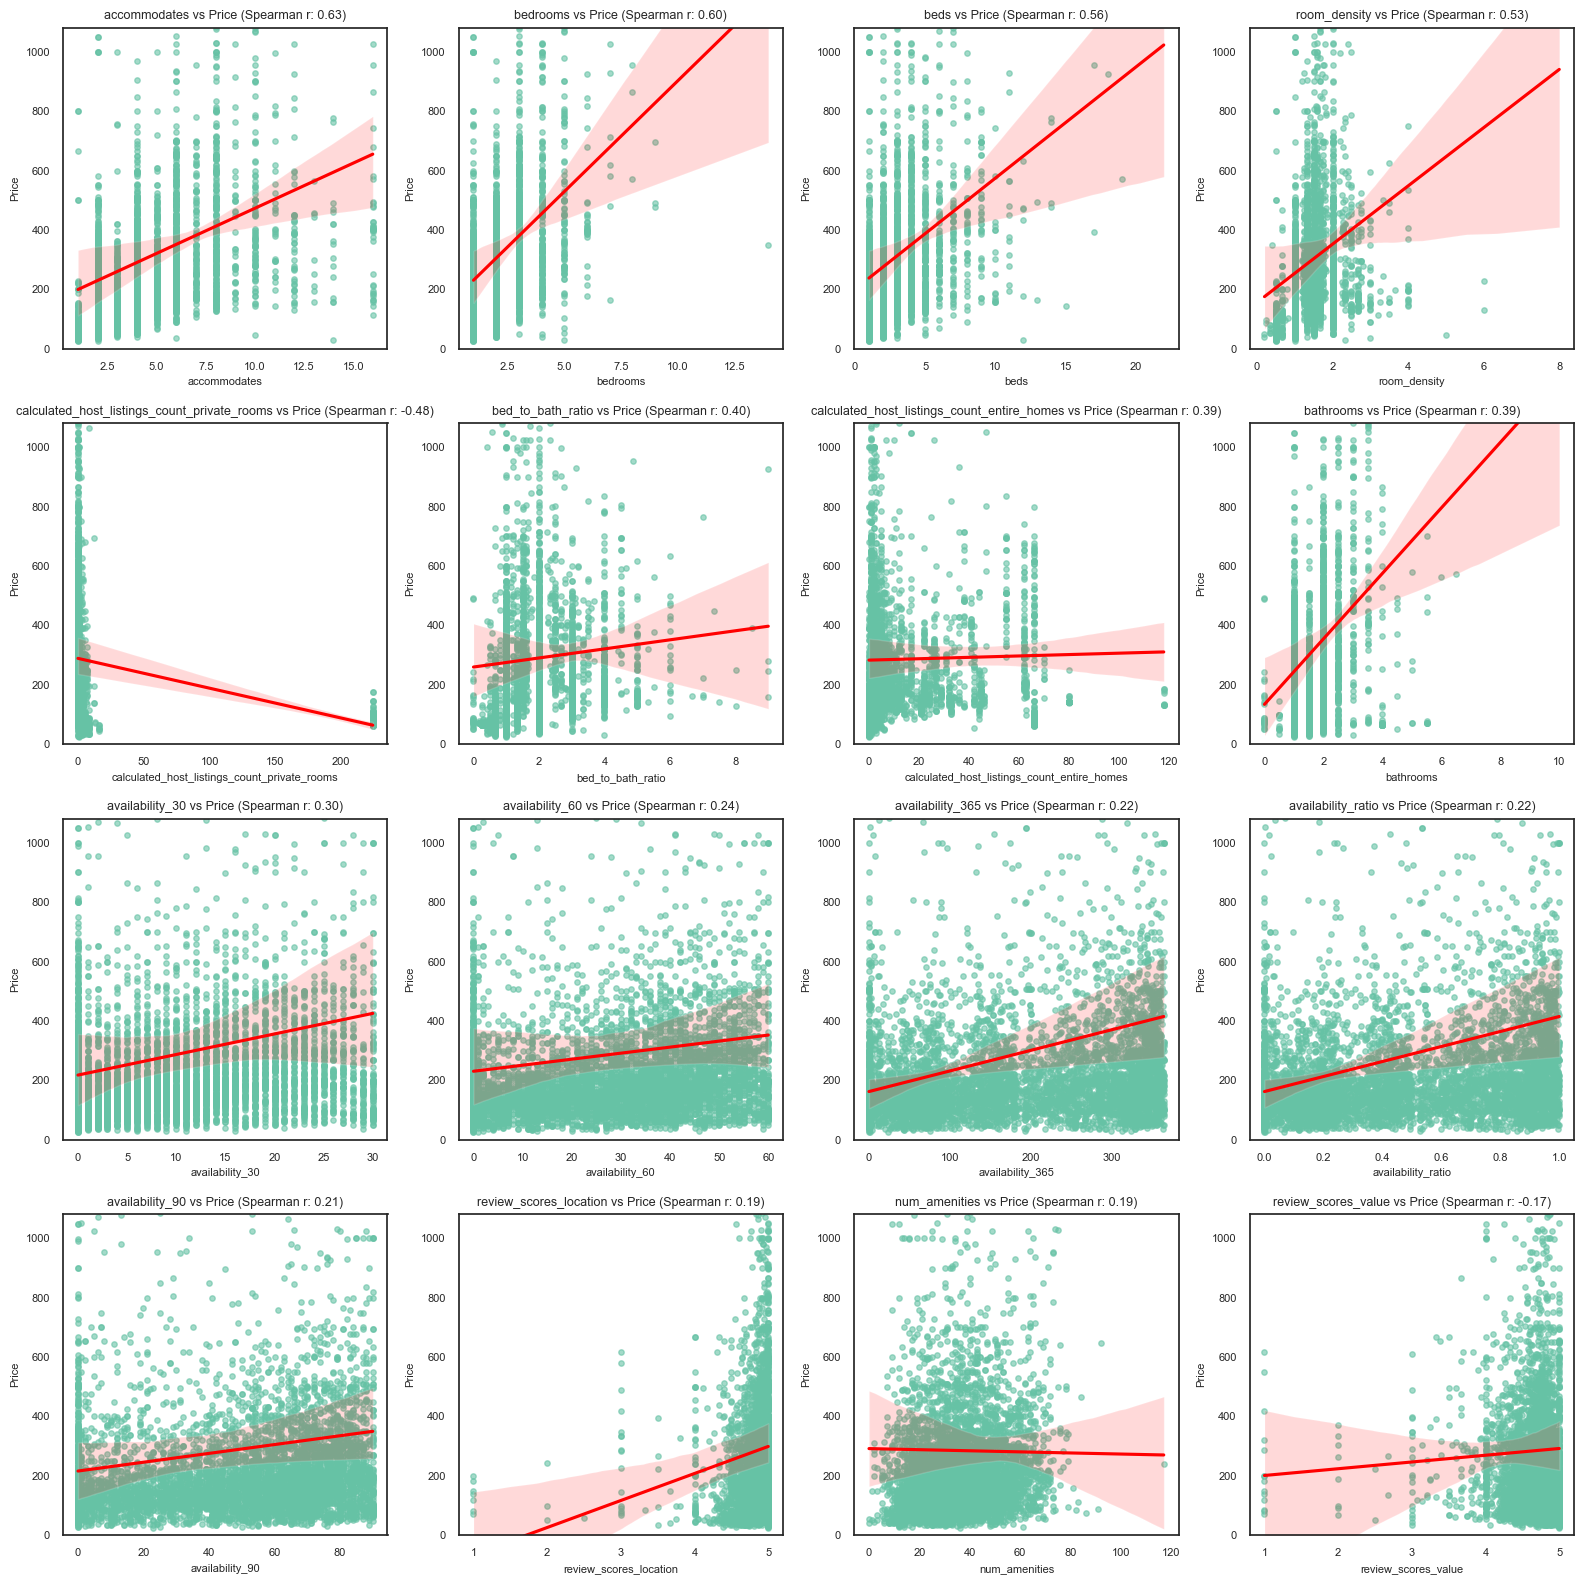

In [43]:
# Visualizing correlations against Price

cols = [col for col in train.columns if col not in ['price']] + ['price']
train = train[cols]

corr = train.select_dtypes(include=['int64', 'float64']).corr(method='spearman')

top_features = (
    corr['price']
    .drop(labels=['price', 'log_price'])
    .abs()
    .sort_values(ascending=False)
    .head(16)
    .index.tolist()
)

# Plot scatter plots
plt.figure(figsize=(16, 16))
for i, feature in enumerate(top_features, 1):
    plt.subplot(4, 4, i)
    
    # Plotting against RAW price
    sns.regplot(x=train[feature], y=train['price'], 
                scatter_kws={'alpha': 0.6, 's': 15}, # Smaller points, lighter alpha for clarity
                line_kws={"color": "red"})
    
    # Set y-axis limit to focus on the bulk of the data and reduce the influence of extreme outliers
    plt.ylim(0, train['price'].quantile(0.99)) 
    plt.title(f"{feature} vs Price (Spearman r: {corr.loc[feature, 'price']:.2f})", fontsize=9)
    plt.xlabel(feature, fontsize=8)
    plt.ylabel("Price", fontsize=8)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

**Top Features Most Correlated with Price**: Taking a closer look at the top 15 features with the highest correlation against `price`:

- **Upward Trend Observed**: Almost all features in the top 15 had an upward trend except for one (`calculated_host_listings_count_private_Rooms`).

- **Size & Capacity Indicators**: The features represent the size and capacity of the listing showed strong upward sloping relationships. Larger properties that accommodate more guests naturally command higher prices.

- **Strong vs Noisy Predictors**: The features `accommodates`, `bedrooms`, `beds`, `bathrooms` are strong predictors while others have low positive and noisy trends.


## 4. Predictive Models

Split train and test set before modeling

In [44]:
# Define target variable
y = train['log_price']

# Define features
X = train.drop(columns=['price', 'log_price'])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (5100, 79)
Test shape: (900, 79)


Ultimately, we aimed to predict Airbnb prices including the use of four machine learning ensemble models based on a number of regressors. This is in line with the philosophy that there's no "one size fits all" in machine learning models and also with the hopes of leveraging on the benefits of synthesizing multiple models to predict the target price variable. 

### 4.1 Base Regressors

First, we trained and fine-tuned **nine regression models** as listed below:

- **Ridge Regression**  (ridge): A linear model that penalizes some features to reduce overfitting by applying a penalty to the model if it tries to use really large weights for any feature. It keeps all features but controls their influence to the final prediction.

- **Lasso Regression**  (lasso): Similar to Ridge, but it can completely eliminate unimportant features. It selects only the most important predictors, which can help simplify the model.

- **Elastic Net**  (elastic): Combines the strengths of Ridge and Lasso and balances between shrinking coefficients and selecting features.

- **Decision Tree**  (dt): A flowchart-like model that splits the data into groups based on conditions and makes predictions by averaging prices in the final group.

- **Random Forest**  (rf): Builds many decision trees and averages their predictions which helps reduce overfitting and gives more stable price predictions.

- **Gradient Boosting** (gbm): Builds trees one at a time with each trying to fix the errors of the previous one.

- **XGBoost**  (xgb): It includes regularization to reduce overfitting and works well even with noisy or messy data.

- **LightGBM** (lgbm): Another GBM variant designed to be lightweight and fast as it uses a different tree-growing strategy that can handle high-dimensional data more efficiently.

- **Support Vector Regression** (svr): Tries to find a flat surface that fits the data within a certain margin of error.

> *Linear regression was also included among the list of regressors but it didn't require tuning.*

In [46]:
# List Regressor Models in a Dictionary (all 9 models)
regressors = {}

# Models with PCA
regressors['lr'] = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)), ("regressor", LinearRegression())])
regressors['ridge'] = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)), ("regressor", Ridge(alpha=100.0))])
regressors['lasso'] = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)), ("regressor", Lasso(alpha=1))])
regressors['elastic'] = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)), ("regressor", ElasticNet(alpha=1, l1_ratio=0.5))])
regressors['svr'] = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)), ("regressor", SVR())])

# No pca for these Models
regressors['rf'] = Pipeline([("regressor", RandomForestRegressor(n_estimators=100, random_state=42))])
regressors['gbm'] = Pipeline([("regressor", GradientBoostingRegressor(n_estimators=100, random_state=42))])
regressors['xgb'] = Pipeline([("regressor", XGBRegressor(n_estimators=100, random_state=42))])
regressors['dt'] = Pipeline([("regressor", DecisionTreeRegressor(random_state=42))])
regressors['lgbm'] = Pipeline([("regressor", LGBMRegressor(n_estimators=100, verbose=-1, random_state=42))])

### 4.2 Model Tuning

Each individual regressor's hyperparameters in the list above were optimized using **randomized search with cross-validation**, where the training data was split into **10 folds** to test how well each model performed. 

- Metric: **Mean Absolute Error (MAE)**
- Iterations: `n = 40` (to search a wide range of combinations)

MAE was also used later to gauge the predictive performance of all the models.

In [ ]:
# Tune the hyperparameters for all models

from scipy.stats import uniform, randint

def tune_all_models(X_train, y_train, regressors, cv=10, scoring="neg_mean_absolute_error", n_iter=40):
    param_grids = {
        'ridge': {
            'pca__n_components': uniform(0.75, 0.25),
            'regressor__alpha': randint(1, 10000)
        },
        'lasso': {
            'pca__n_components': uniform(0.75, 0.25),
            'regressor__alpha': uniform(0.0001, 1000)
        },
        'elastic': {
            'pca__n_components': uniform(0.75, 0.25),
            'regressor__alpha': uniform(0.0001, 1000),
            'regressor__l1_ratio': uniform(0, 1)
        },
        'rf': {
            'regressor__n_estimators': randint(500, 1000),
            'regressor__max_depth': randint(10, 50),
            'regressor__min_samples_split': randint(2, 20),
            'regressor__min_samples_leaf': randint(1, 10),
            'regressor__max_features': ['auto', 'sqrt', 'log2', 0.6, 0.8],
            "regressor__bootstrap": [True, False]
        },
        'gbm': {
            'regressor__n_estimators': randint(100, 500),
            'regressor__learning_rate': uniform(0.001, 0.3),
            'regressor__max_depth': randint(3, 10),
            'regressor__subsample': uniform(0.5, 0.5),
            'regressor__min_samples_split': randint(2, 20),
            "regressor__min_samples_leaf": [1, 2, 3],
            "regressor__max_features": ['sqrt', 'log2', 0.6, 0.8]
        },
        'xgb': {
            'regressor__n_estimators': randint(100, 300),
            'regressor__learning_rate': uniform(0.001, 0.5),
            'regressor__max_depth': randint(3, 10),
            'regressor__subsample': uniform(0.5, 1.5),
            'regressor__colsample_bytree': uniform(0.5, 1.5),
            "regressor__reg_alpha": [0.1, 1, 3],
            "regressor__reg_lambda": [0.05, 0.1, 1],
            "regressor__gamma": [3, 5, 7],
            'regressor__min_child_weight': [1, 3, 5]
        },
        'dt': {
            'regressor__max_depth': randint(1, 100),
            'regressor__min_samples_split': randint(2, 20),
            'regressor__min_samples_leaf': randint(1, 10),
            'regressor__max_features': ['auto', 'sqrt', 'log2']
        },
        'svr': {
            'pca__n_components': uniform(0.75, 0.25),
            'regressor__C': uniform(0.1, 100),
            'regressor__epsilon': uniform(0.01, 10),
            'regressor__kernel': ['rbf', 'linear'],
            'regressor__gamma': ['scale', 'auto']
        },
        'lgbm': {
            'regressor__n_estimators': randint(200, 500),
            'regressor__learning_rate': uniform(0.001, 0.5),
            'regressor__num_leaves': randint(10, 100),
            'regressor__subsample': uniform(0.5, 1.0),
            'regressor__colsample_bytree': uniform(0.5, 0.5),
            'regressor__reg_lambda': uniform(0, 20)
        }
    }

    for name in param_grids:
        print(f"\nTuning: {name}")
        model = clone(regressors[name])
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=n_iter,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            refit=True,
            random_state=42
        )
        search.fit(X_train, y_train)
        regressors[name] = search.best_estimator_
        print(f"Best params for {name}: {search.best_params_}")

    return regressors

In [48]:
best_models = tune_all_models(X_train, y_train, regressors)


Tuning: ridge
Best params for ridge: {'pca__n_components': 0.995807721451697, 'regressor__alpha': 1529}

Tuning: lasso
Best params for lasso: {'pca__n_components': 0.8436350297118407, 'regressor__alpha': 950.7144064099161}

Tuning: elastic
Best params for elastic: {'pca__n_components': 0.8436350297118407, 'regressor__alpha': 950.7144064099161, 'regressor__l1_ratio': 0.7319939418114051}

Tuning: rf
Best params for rf: {'regressor__bootstrap': False, 'regressor__max_depth': 36, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 4, 'regressor__n_estimators': 712}

Tuning: gbm
Best params for gbm: {'regressor__learning_rate': 0.04870505824520566, 'regressor__max_depth': 9, 'regressor__max_features': 0.6, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 6, 'regressor__n_estimators': 198, 'regressor__subsample': 0.7956488938538635}

Tuning: xgb
Best params for xgb: {'regressor__colsample_bytree': 0.5678409333658071, 'regress

### 4.3 Discussion on Tuning the Hyperparameters

In tuning the hyperparameters, **randomized search** is applied to maximize our laptops as running the code required plenty of computing power.

All regressors were tuned using **10-fold cross-validation** with **negative mean absolute error (MAE)** as the optimization metric to align with the competition's key metric. This approach ensured that model performance was assessed reliably across different data partitions, helping mitigate issues such as overfitting or data leakage.

A diverse range of optimal configurations is used to capture the best possible settings. The number of parameter combinations was set to `n_iter = 40`, allowing the tuning process to explore a wide range of possible combinations.

In [64]:
# Rank individual regressors based on MAEs for train and test datasets

cv_scores = {}

for name, model in best_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring="neg_mean_absolute_error", n_jobs=-1)
    mae_cv = -scores.mean()
    cv_scores[name] = {'MAE_train': mae_cv}

# Convert to DataFrame and rank by MAE
cv_df = pd.DataFrame(cv_scores).T
cv_df['Rank_MAE_train'] = cv_df['MAE_train'].rank(method='min')
cv_df_sorted = cv_df.sort_values('Rank_MAE_train')

test_metrics = {}

for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_metrics[name] = {'MAE_test': mean_absolute_error(y_test, y_pred)}

# Convert to DataFrame and rank by MAE
test_df = pd.DataFrame(test_metrics).T
test_df['Rank_MAE_test'] = test_df['MAE_test'].rank(method='min')
test_df_sorted = test_df.sort_values('Rank_MAE_test')

test_df_with_names = test_df_sorted.reset_index().rename(columns={'index': 'Model'})
cv_df_sorted_with_names = cv_df_sorted.reset_index().rename(columns={'index': 'Model'})

regressors_df = pd.merge(cv_df_sorted_with_names, test_df_with_names, on='Model', how='left')

rank_df = regressors_df.copy()
rank_df['Avg_Rank'] = rank_df[['Rank_MAE_train', 'Rank_MAE_test']].mean(axis=1)
rank_df_sorted = rank_df.sort_values('Avg_Rank').reset_index(drop=True)
rank_df_sorted = rank_df_sorted.round(5)
rank_df_sorted

,Model,MAE_train,Rank_MAE_train,MAE_test,Rank_MAE_test,Avg_Rank
0,lgbm,0.23676,1.0,0.22731,1.0,1.0
1,gbm,0.24070,2.0,0.22794,2.0,2.0
2,rf,0.24985,3.0,0.23186,3.0,3.0
3,xgb,0.27831,4.0,0.25496,4.0,4.0
4,svr,0.30083,5.0,0.27864,5.0,5.0
5,ridge,0.30811,6.0,0.28100,6.0,6.0
6,lr,0.31490,7.0,0.28938,7.0,7.0
7,dt,0.34412,8.0,0.31850,8.0,8.0
8,lasso,0.53046,9.0,0.49690,9.0,9.0
9,elastic,0.53046,9.0,0.49690,9.0,9.0


All models showed distinct optimal configurations. 
- Linear models favored high PCA retention with moderate-to-low regularization. 
- Tree-based models like RF, GBM, and XGBoost benefited from deep trees and large estimator counts while boosting models had low learning rates.
- VR and LightGBM required balancing of complexity and regularization. 

Overall, these hyperparameters show that simpler models benefited from regularization and dimensionality reduction, while complex models required finely tuned learning controls. This tuning process shall now form as the foundation of ensemble modeling.

### 4.4 Ensemble Models

Once identified the best hyperparameters for each regressor, **four ensemble models** are built:

**1. Voting Regressor (Top 5 Models)**:

Uses predictions from the **five best (lowest MAEs)** individual models: LightGBM, Gradient Boosting, Random Forest, XGBoost and Support Vector Regression

Averages them to make the final prediction. The averaging smooths out extreme predictions and mitigates individual model biases for more stable output.

**2. Stacking Regressor (Top 5 Models)**:

Uses the same top five models as above to create meta-features. A linear Regressor is used as the final estimator, which learns the optimal combination of the base models’ predictions.

**3. Voting Regressor (All Models)**:

Uses all individual regressors, regardless of individual performance, and averages their predictions. This leverages the diversity of models, even if some are weak learners.

**4. Stacking Regressor (All Models)**

Same as above but applies stacking. All base models contribute to first-layer predictions, and a Linear Regressor again acts as the meta-learner. This gives each model a chance to contribute as long as it improves accuracy.

In [50]:
# Create and fit top 5 regressors for stacking and voting ensembles

estimators = [
    ('xgb', best_models['xgb']),
    ('gbm', best_models['gbm']),
    ('svr', best_models['svr']),
    ('lgbm', best_models['lgbm']),
    ('rf', best_models['rf'])]

# Trying the stacking model top five

stacking_top_five = StackingRegressor(estimators=estimators, final_estimator=LinearRegression(), n_jobs=-1)
stacking_top_five.fit(X_train, y_train)

StackingRegressor(estimators=[('xgb',
                               Pipeline(steps=[('regressor',
                                                XGBRegressor(base_score=None,
                                                             booster=None,
                                                             callbacks=None,
                                                             colsample_bylevel=None,
                                                             colsample_bynode=None,
                                                             colsample_bytree=0.5678409333658071,
                                                             device=None,
                                                             early_stopping_rounds=None,
                                                             enable_categorical=False,
                                                             eval_metric=None,
                                                             feature_types=None,
                                                             feature_weights=None,
                                                             gamma=3,
                                                             grow_policy=None,...
                                                              learning_rate=0.062019117422389414,
                                                              n_estimators=363,
                                                              num_leaves=44,
                                                              random_state=42,
                                                              reg_lambda=18.186408041575643,
                                                              subsample=0.7587799816000169,
                                                              verbose=-1))])),
                              ('rf',
                               Pipeline(steps=[('regressor',
                                                RandomForestRegressor(bootstrap=False,
                                                                      max_depth=36,
                                                                      max_features='log2',
                                                                      min_samples_split=4,
                                                                      n_estimators=712,
                                                                      random_state=42))]))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [51]:
# Weights of the base regressors in the stack five model

meta_model_stackfive = stacking_top_five.final_estimator_
weights = meta_model_stackfive.coef_

model_names_stackfive = [name for name, _ in stacking_top_five.estimators]
weights_stackfive = pd.DataFrame({'Base Model': model_names_stackfive,'Weight': weights}).sort_values(by='Weight', ascending=False)

print(weights_stackfive)

  Base Model    Weight
3       lgbm  0.614703
4         rf  0.403226
1        gbm  0.231196
2        svr  0.025235
0        xgb -0.230615


The weights of the stacking model show the degree of contribution each individual model's prediction affect the final prediction. This is different to a voting model where each prediction of the individual models in the ensemble have equal weight. It is also different to the individual regressors where the weights represent the contribution of each feature to the model's prediction.

In [52]:
# Trying the voting ensemble top five

voting_top_five = VotingRegressor(estimators=estimators, n_jobs=-1)
voting_top_five.fit(X_train, y_train)

VotingRegressor(estimators=[('xgb',
                             Pipeline(steps=[('regressor',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=0.5678409333658071,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=False,
                                                           eval_metric=None,
                                                           feature_types=None,
                                                           feature_weights=None,
                                                           gamma=3,
                                                           grow_policy=None,
                                                           im...
                                              LGBMRegressor(colsample_bytree=0.7200762468698007,
                                                            learning_rate=0.062019117422389414,
                                                            n_estimators=363,
                                                            num_leaves=44,
                                                            random_state=42,
                                                            reg_lambda=18.186408041575643,
                                                            subsample=0.7587799816000169,
                                                            verbose=-1))])),
                            ('rf',
                             Pipeline(steps=[('regressor',
                                              RandomForestRegressor(bootstrap=False,
                                                                    max_depth=36,
                                                                    max_features='log2',
                                                                    min_samples_split=4,
                                                                    n_estimators=712,
                                                                    random_state=42))]))],
                n_jobs=-1)

In [53]:
# Create and fit all regressors for stacking and voting ensembles

estimatorsall = [
    ('xgb', best_models['xgb']),
    ('gbm', best_models['gbm']),
    ('svr', best_models['svr']),
    ('lgbm', best_models['lgbm']),
    ('rf', best_models['rf']),
    ('dt', best_models['dt']),
    ('ridge', best_models['ridge']),
    ('lasso', best_models['lasso']),
    ('elastic', best_models['elastic']),
    ('lr', regressors['lr'])]

stacking_all = StackingRegressor(estimators=estimatorsall, final_estimator=LinearRegression(), n_jobs=-1)
stacking_all.fit(X_train, y_train)

StackingRegressor(estimators=[('xgb',
                               Pipeline(steps=[('regressor',
                                                XGBRegressor(base_score=None,
                                                             booster=None,
                                                             callbacks=None,
                                                             colsample_bylevel=None,
                                                             colsample_bynode=None,
                                                             colsample_bytree=0.5678409333658071,
                                                             device=None,
                                                             early_stopping_rounds=None,
                                                             enable_categorical=False,
                                                             eval_metric=None,
                                                             feature_types=None,
                                                             feature_weights=None,
                                                             gamma=3,
                                                             grow_policy=None,...
                                                Lasso(alpha=950.7144064099161))])),
                              ('elastic',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('pca',
                                                PCA(n_components=0.8436350297118407)),
                                               ('regressor',
                                                ElasticNet(alpha=950.7144064099161,
                                                           l1_ratio=0.7319939418114051))])),
                              ('lr',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('pca', PCA(n_components=0.95)),
                                               ('regressor',
                                                LinearRegression())]))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [54]:
# Weights of the base regressors in the stack all model

meta_model_stacking_all = stacking_all.final_estimator_
weights = meta_model_stacking_all.coef_

model_names_stacking_all = [name for name, _ in stacking_all.estimators]
weights_stacking_all = pd.DataFrame({'Base Model': model_names_stacking_all,'Weight': weights}).sort_values(by='Weight', ascending=False)

print(weights_stacking_all)

  Base Model    Weight
3       lgbm  0.603996
4         rf  0.376739
6      ridge  0.370858
1        gbm  0.246402
2        svr  0.022935
5         dt -0.009403
9         lr -0.263371
0        xgb -0.270668
8    elastic -0.838572
7      lasso -0.838572


In [55]:
# Running for voting all ensemble
voting_all = VotingRegressor(estimators=estimatorsall, n_jobs=-1)
voting_all.fit(X_train, y_train)

VotingRegressor(estimators=[('xgb',
                             Pipeline(steps=[('regressor',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=0.5678409333658071,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=False,
                                                           eval_metric=None,
                                                           feature_types=None,
                                                           feature_weights=None,
                                                           gamma=3,
                                                           grow_policy=None,
                                                           im...
                                             ('regressor',
                                              Lasso(alpha=950.7144064099161))])),
                            ('elastic',
                             Pipeline(steps=[('scaler', StandardScaler()),
                                             ('pca',
                                              PCA(n_components=0.8436350297118407)),
                                             ('regressor',
                                              ElasticNet(alpha=950.7144064099161,
                                                         l1_ratio=0.7319939418114051))])),
                            ('lr',
                             Pipeline(steps=[('scaler', StandardScaler()),
                                             ('pca', PCA(n_components=0.95)),
                                             ('regressor',
                                              LinearRegression())]))],
                n_jobs=-1)

In [56]:
# Compute training MAE
mae_train_stackfive = mean_absolute_error(y_train, stacking_top_five.predict(X_train))
mae_train_votfive   = mean_absolute_error(y_train, voting_top_five.predict(X_train))
mae_train_stackall  = mean_absolute_error(y_train, stacking_all.predict(X_train))
mae_train_votall    = mean_absolute_error(y_train, voting_all.predict(X_train))

# Compute test MAE
mae_test_stackfive = mean_absolute_error(y_test, stacking_top_five.predict(X_test))
mae_test_votfive   = mean_absolute_error(y_test, voting_top_five.predict(X_test))
mae_test_stackall  = mean_absolute_error(y_test, stacking_all.predict(X_test))
mae_test_votall    = mean_absolute_error(y_test, voting_all.predict(X_test))

# Create DataFrame
ensemble_mae_df = pd.DataFrame([
    {'Model': 'stacking_top_five', 'MAE_train': mae_train_stackfive, 'MAE_test': mae_test_stackfive},
    {'Model': 'voting_top_five',   'MAE_train': mae_train_votfive,   'MAE_test': mae_test_votfive},
    {'Model': 'stacking_all',      'MAE_train': mae_train_stackall,  'MAE_test': mae_test_stackall},
    {'Model': 'voting_all',        'MAE_train': mae_train_votall,    'MAE_test': mae_test_votall},])

In [57]:
regressors_mae_df = regressors_df[['Model', 'MAE_train', 'MAE_test']].copy()
result_summary = pd.concat([regressors_mae_df, ensemble_mae_df], axis = 0)

result_summary = (result_summary.assign(
        Rank_MAE_train = result_summary['MAE_train'].rank(method='min'),
        Rank_MAE_test = result_summary['MAE_test'].rank(method='min'))
    .assign(Average_Rank = lambda df: df[['Rank_MAE_train', 'Rank_MAE_test']].mean(axis=1)).sort_values('Average_Rank').reset_index(drop=True))

result_summary.round(5)

,Model,MAE_train,MAE_test,Rank_MAE_train,Rank_MAE_test,Average_Rank
0,stacking_top_five,0.05384,0.21968,1.0,2.0,1.5
1,stacking_all,0.05725,0.21802,2.0,1.0,1.5
2,voting_top_five,0.10726,0.22674,3.0,3.0,3.0
3,lgbm,0.23676,0.22731,5.0,4.0,4.5
4,gbm,0.24070,0.22794,6.0,5.0,5.5
5,voting_all,0.21353,0.26157,4.0,8.0,6.0
6,rf,0.24985,0.23186,7.0,6.0,6.5
7,xgb,0.27831,0.25496,8.0,7.0,7.5
8,svr,0.30083,0.27864,9.0,9.0,9.0
9,ridge,0.30811,0.28100,10.0,10.0,10.0


We used **10-fold cross-validation** with `mean_absolute_error` as the scoring metric to assess the model's performance on the training dataset. This ensures robust evaluation and reduces variance in the performance estimate. 

The table above shows the performance of each regressor and the ensemble models ranked according to their **MAE score** for the train and test data.

- Ensemble models including `stacking_top_five`, `stacking_all` all tie at Average rank 1.5 as expected. The two `top_five` models has higher MAE_test than ensemble models of all base regressors suggests the bottom model (linears and decision tree) are adding noise rather than value.

- Among individual regressors, Gradient Boosting (GBM), LightGBM (lgbm) and Random Forest (rf) consistently showed strong performance, with test MAEs around 0.22-0.25.

- Simpler models such as Lasso, Ridge, and Linear Regression (lr) performed poorly, with very high MAE values, indicating underfitting and an inability to capture the nonlinear complexity of the data.
- Support Vector Regression (SVR) and XGBoost (xgb) performed moderately but did not surpass ensemble methods.

Overall, the results confirm that ensemble strategies, particularly voting and stacking of the top-performing base models, lead to significantly better accuracy and stability across data splits.

#### **Final model for prediction**

The **ensemble models** had the best performance among all predictive models.

> ✅ **The final model** for the price prediction is a `StackingRegressor using the top 5` individually tuned base models:
>
> - XGBoost  
> - Gradient Boosting  
> - Support Vector Regression  
> - LightGBM  
> - Random Forest

These models were combined using different weight as below:
| Base Model | Weight |
|:---|:---|
| lgbm | 0.614703 |
| rf | 0.403226 |
| gbm | 0.231196 |
| svr | 0.025235 |
| xgb | -0.230615 |


The stacking meta-learner (Linear Regression) found that subtracting a portion of XGB's predictions improves the final output. This happens when XGB's predictions are correlated with errors in the other models, the meta-learner learns to use XGB as a correction signal rather than a direct contributor.

LGBM (0.61) and RF (0.40) are doing the heavy lifting, GBM (0.23) adds moderate contribution, SVR (0.03) barely contributes, and XGB (-0.23) acts as a correction term. This is a reasonable outcome from MAE rankings where LGBM and GBM were consistently the strongest individual models.

#### **Feature Importance for base regressors in `stacking_top_five` model**

**Feature Importance** is performed for 4 tree-based models in `stacking_top_five` including LightGBM, Random Forest, Gradient Boosting and XGBoosting. We do not perform feature importance for SVR because it only has a weight of 0.025 in the stacking model and SVR feature importance is not directly extractable due to the RBF kernel.

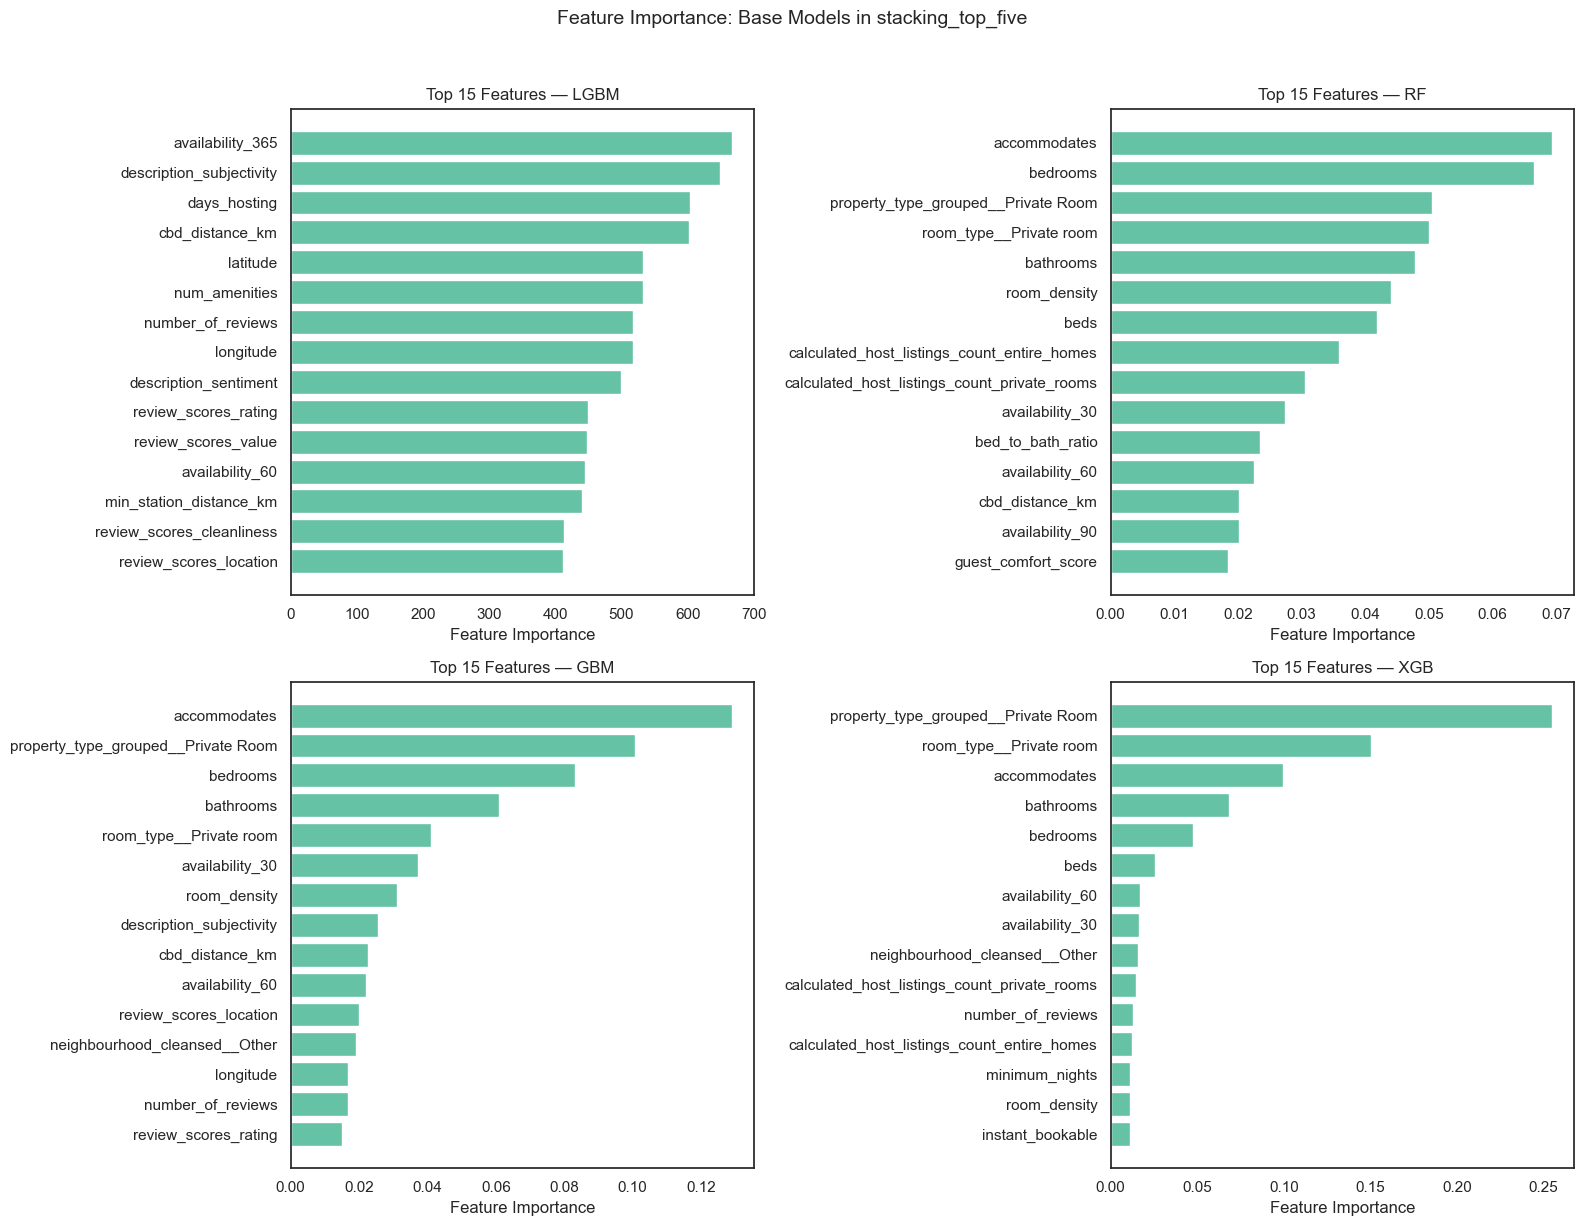

In [74]:
# After fitting stacking_top_five

tree_models = ['lgbm', 'rf', 'gbm', 'xgb']  # exclude svr — no feature importance

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(tree_models):
    # Access the fitted base estimator from the stacking model
    fitted_estimator = stacking_top_five.named_estimators_[name]
    
    # Extract the regressor step from the pipeline
    regressor = fitted_estimator.named_steps['regressor']
    
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': regressor.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    axes[i].barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
    axes[i].set_title(f'Top 15 Features — {name.upper()}')
    axes[i].set_xlabel('Feature Importance')

plt.suptitle('Feature Importance: Base Models in stacking_top_five', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Feature importance analysis across the four tree-based base models reveals consistent and complementary patterns:

- **Capacity features dominate universally**:`accommodates`, `bedrooms`, `bathrooms`, and `beds` appear in every model's top 15, confirming property size as the strongest predictor of listing price

- **Property and room type are critical** : `property_type_grouped__Private Room` and `room_type__Private room` rank highest in XGB and GBM, reflecting that entire home vs private room is the single most impactful pricing factor

- **LGBM captures distinct signals**: unlike the other models, LGBM's top features include `availability_365`, `description_subjectivity`, `days_hosting`, and geographic coordinates, indicating it learns from host behaviour and listing presentation rather than just physical attributes

- **Engineered features add valuable predictive signals**: `cbd_distance_km`, `room_density`, `description_subjectivity`, and `min_station_distance_km` appear across multiple models, validating the feature engineering process

- **Ensemble diversity is a strength**: the divergence between LGBM and the other models confirms each base model captures different pricing signals, which is why combining them outperforms any single model

### Create predictions of the test dataset

In [60]:
# Reassign cleaned test dataset to dataframe for predictions

test_copy = test.copy()
X_compete = test_copy

In [61]:
# Predict on log scale, then convert back to dollar scale
y_test_stacking_top_five = np.expm1(stacking_top_five.predict(X_compete))

# Add predictions to the test DataFrame
test_copy['price'] = y_test_stacking_top_five

In [62]:
# Prepare csv for submission

test_org = pd.read_csv('test.csv')

test_copy['ID'] = test_org['ID'].values

submit = test_copy[['ID', 'price']]

# Dumping the predictions into a csv file.
submit.to_csv("prediction_stacking_top_five.csv",index = False)